In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyarrow.parquet as pq
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (12, 6)


In [2]:
data_path = Path("/Users/kierangivens/Downloads/softcite-extractions-oa-data/p05_five_percent_random_subset/")

files = {
    "papers": data_path / "papers.parquet",
    "mentions": data_path / "mentions.pdf.parquet",
    "purpose_assessments": data_path / "purpose_assessments.pdf.parquet",
}

# Check if all files exist
print("Checking files...")
for file in files.values():
    print(f"{file.name}: {'found' if file.exists() else 'missing'}")

if all(file.exists() for file in files.values()):
    print("All files found. Ready to load data.")
else:
    print("Some files are missing. Check the folder path.")


Checking files...
papers.parquet: found
mentions.pdf.parquet: found
purpose_assessments.pdf.parquet: found
All files found. Ready to load data.


In [3]:
print("Loading parquet files")

papers_df = pd.read_parquet(files['papers'], engine="pyarrow")
print(f"Papers dataset: {papers_df.shape[0]:,} rows, {papers_df.shape[1]} columns")

mentions_df = pd.read_parquet(files['mentions'], engine="pyarrow")
print(f"Mentions dataset: {mentions_df.shape[0]:,} rows, {mentions_df.shape[1]} columns")

purpose_df = pd.read_parquet(files['purpose_assessments'], engine="pyarrow")
print(f"Purpose assessments dataset: {purpose_df.shape[0]:,} rows, {purpose_df.shape[1]} columns")

print("\nData loaded successfully")


Loading parquet files
Papers dataset: 320,866 rows, 13 columns
Mentions dataset: 2,777,758 rows, 15 columns
Purpose assessments dataset: 16,666,548 rows, 7 columns

Data loaded successfully


# Look at the initial heads for the dataframes


In [4]:
papers_df.head()

,paper_id,softcite_id,title,published_year,published_date,publication_venue,publisher_name,doi,pmcid,pmid,genre,license_type,has_mentions
0,84,00003a57-7df8-4951-bc85-8b49e7b8d8ad,Scalability and feasibility of photoelectroche...,2015,2015-01-01,Energy &amp; Environmental Science,Royal Society of Chemistry (RSC),10.1039/c5ee02188j,,,journal-article,,True
1,165,00007678-4c96-4f8f-af0b-a9057e609234,Early prediction of paratuberculosis health st...,2022,2022-08-12,,Research Square Platform LLC,10.21203/rs.3.rs-1929091/v1,,,posted-content,,True
2,196,00008d79-abca-4c1b-a995-d7452bd804de,A Comparison of DNA Pools Constructed Followin...,2005,2005-08-01,Twin Research and Human Genetics,Cambridge University Press (CUP),10.1375/1832427054936718,,,journal-article,,True
3,294,0000d6e5-ae77-4518-9a28-0560b77401aa,DicomBrowser: Software for Viewing and Modifyi...,2012,2012-02-15,Journal of Digital Imaging,Springer Science and Business Media LLC,10.1007/s10278-012-9462-x,PMC3447088,22349992,journal-article,,True
4,313,0000e448-bd17-4865-913b-9ee4e483edd4,Validation of the Arabic version of the SCOFF ...,2015,2015-05-01,Eastern Mediterranean Health Journal,World Health Organization Regional Office for ...,10.26719/2015.21.5.326,,26343121,journal-article,,True


In [5]:
mentions_df.head()

,software_mention_id,paper_id,source_file_type,mention_index,software_raw,software_normalized,version_raw,version_normalized,publisher_raw,publisher_normalized,language_raw,language_normalized,url_raw,url_normalized,context_full_text
0,84.pdf.00000,84,pdf,0,ImageJ,ImageJ,,,,,,,,,The size of the nanoparticles on the pictures ...
1,84.pdf.00001,84,pdf,1,EC Lab,EC Lab,,,,,,,,,"For the photoelectrochemical measurements, a B..."
2,165.pdf.00000,165,pdf,0,MagMET,MagMET,,,,,,,,,MagMET allows for qualitative and quantitative...
3,165.pdf.00001,165,pdf,1,AVAILABILITY STATEMENT,AVAILABILITY STATEMENT,,,,,,,,,SOFTWARE OR DATABASE AVAILABILITY STATEMENT T...
4,165.pdf.00002,165,pdf,2,Metaboanalyst,Metaboanalyst,,,,,,,www.metaboanalyst.ca,www.metaboanalyst.ca,Since the pathway analysis on the Metaboanalys...


In [6]:
purpose_df.head(40)

,software_mention_id,paper_id,source_file_type,mention_index,scope,purpose,certainty_score
0,84.pdf.00000,84,pdf,0,document,created,6.556511e-06
1,84.pdf.00000,84,pdf,0,document,shared,1.192093e-07
2,84.pdf.00000,84,pdf,0,document,used,9.999969e-01
3,84.pdf.00000,84,pdf,0,local,created,6.556511e-06
4,84.pdf.00000,84,pdf,0,local,shared,1.192093e-07
5,84.pdf.00000,84,pdf,0,local,used,9.999969e-01
6,84.pdf.00001,84,pdf,1,document,created,4.541874e-05
7,84.pdf.00001,84,pdf,1,document,shared,1.192093e-07
8,84.pdf.00001,84,pdf,1,document,used,9.999943e-01
9,84.pdf.00001,84,pdf,1,local,created,4.541874e-05


## Section 2: Dataset Overview

Schema, data types, descriptive statistics, and checking for missing values for each table

In [7]:
print("PAPERS TABLE")
papers_df.info()
print()
papers_df.describe(include="all")

PAPERS TABLE
<class 'pandas.DataFrame'>
RangeIndex: 320866 entries, 0 to 320865
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   paper_id           320866 non-null  uint32
 1   softcite_id        320866 non-null  str   
 2   title              320866 non-null  str   
 3   published_year     320866 non-null  uint16
 4   published_date     320866 non-null  object
 5   publication_venue  320866 non-null  str   
 6   publisher_name     320866 non-null  str   
 7   doi                320866 non-null  str   
 8   pmcid              320866 non-null  str   
 9   pmid               320866 non-null  str   
 10  genre              320866 non-null  str   
 11  license_type       320866 non-null  str   
 12  has_mentions       320866 non-null  bool  
dtypes: bool(1), object(1), str(9), uint16(1), uint32(1)
memory usage: 101.1+ MB



,paper_id,softcite_id,title,published_year,published_date,publication_venue,publisher_name,doi,pmcid,pmid,genre,license_type,has_mentions
count,3.208660e+05,320866,320866,320866.000000,320866,320866,320866,320866,320866,320866,320866,320866,320866
unique,NaN,320866,318558,NaN,8784,45527,9586,320866,113126,144087,29,9,1
top,NaN,00003a57-7df8-4951-bc85-8b49e7b8d8ad,,NaN,1970-01-01,,Springer Science and Business Media LLC,10.1039/c5ee02188j,,,journal-article,,True
freq,NaN,1,1118,NaN,6682,34926,36781,1,207726,176762,261299,240375,320866
mean,1.187695e+07,NaN,NaN,1975.052467,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,6.859927e+06,NaN,NaN,285.311313,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,8.400000e+01,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,5.929754e+06,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1.189220e+07,NaN,NaN,2018.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.782157e+07,NaN,NaN,2021.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
print("MENTIONS TABLE")
mentions_df.info()
print()
mentions_df.describe(include="all")

MENTIONS TABLE
<class 'pandas.DataFrame'>
RangeIndex: 2777758 entries, 0 to 2777757
Data columns (total 15 columns):
 #   Column                Dtype 
---  ------                ----- 
 0   software_mention_id   str   
 1   paper_id              uint32
 2   source_file_type      str   
 3   mention_index         uint16
 4   software_raw          str   
 5   software_normalized   str   
 6   version_raw           str   
 7   version_normalized    str   
 8   publisher_raw         str   
 9   publisher_normalized  str   
 10  language_raw          str   
 11  language_normalized   str   
 12  url_raw               str   
 13  url_normalized        str   
 14  context_full_text     str   
dtypes: str(13), uint16(1), uint32(1)
memory usage: 860.4 MB



,software_mention_id,paper_id,source_file_type,mention_index,software_raw,software_normalized,version_raw,version_normalized,publisher_raw,publisher_normalized,language_raw,language_normalized,url_raw,url_normalized,context_full_text
count,2777758,2.777758e+06,2777758,2.777758e+06,2777758,2777758,2777758,2777758,2777758,2777758,2777758,2777758,2777758,2777758,2777758
unique,2777758,NaN,1,NaN,234137,221434,19461,18744,28538,25062,184,179,21782,21484,2123899
top,84.pdf.00000,NaN,pdf,NaN,LaTeX,LaTeX,,,,,,,,,An error in the conversion from LaTeX to XML h...
freq,1,NaN,2777758,NaN,117252,117252,2220254,2220254,2457319,2457319,2713359,2713359,2679639,2679639,35023
mean,NaN,1.179244e+07,NaN,2.352688e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,6.804224e+06,NaN,1.990968e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,8.400000e+01,NaN,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,5.994680e+06,NaN,2.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,1.164916e+07,NaN,1.200000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,1.764336e+07,NaN,4.300000e+01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
print("PURPOSE ASSESSMENTS TABLE")
purpose_df.info()
print()
purpose_df.describe(include="all")

PURPOSE ASSESSMENTS TABLE
<class 'pandas.DataFrame'>
RangeIndex: 16666548 entries, 0 to 16666547
Data columns (total 7 columns):
 #   Column               Dtype  
---  ------               -----  
 0   software_mention_id  str    
 1   paper_id             uint32 
 2   source_file_type     str    
 3   mention_index        uint16 
 4   scope                str    
 5   purpose              str    
 6   certainty_score      float64
dtypes: float64(1), str(4), uint16(1), uint32(1)
memory usage: 1.3 GB



,software_mention_id,paper_id,source_file_type,mention_index,scope,purpose,certainty_score
count,16666548,1.666655e+07,16666548,1.666655e+07,16666548,16666548,1.666655e+07
unique,2777758,NaN,1,NaN,2,3,NaN
top,84.pdf.00000,NaN,pdf,NaN,document,created,NaN
freq,6,NaN,16666548,NaN,8333274,5555516,NaN
mean,NaN,1.179244e+07,NaN,2.352688e+02,NaN,NaN,3.281964e-01
std,NaN,6.804223e+06,NaN,1.990968e+03,NaN,NaN,4.530572e-01
min,NaN,8.400000e+01,NaN,0.000000e+00,NaN,NaN,1.192093e-07
25%,NaN,5.994680e+06,NaN,2.000000e+00,NaN,NaN,1.788139e-06
50%,NaN,1.164916e+07,NaN,1.200000e+01,NaN,NaN,2.143979e-04
75%,NaN,1.764336e+07,NaN,4.300000e+01,NaN,NaN,9.945893e-01


In [10]:
def missing_report(df, name):
    total = len(df)
    rows = []
    for col in df.columns:
        s = df[col]
        nan_ct = s.isna().sum()
        if s.dtype == object or pd.api.types.is_string_dtype(s):
            empty_ct = (s.astype("string").str.strip() == "").sum()
        else:
            empty_ct = 0
        rows.append({
            "table": name,
            "column": col,
            "nan": int(nan_ct),
            "empty_str": int(empty_ct),
            "pct_missing": round((nan_ct + empty_ct) / total * 100, 2),
        })
    return pd.DataFrame(rows)

missing_papers   = missing_report(papers_df,  "papers")
missing_mentions = missing_report(mentions_df, "mentions")
missing_purpose  = missing_report(purpose_df,  "purpose_assessments")

missing_all = pd.concat([missing_papers, missing_mentions, missing_purpose], ignore_index=True)
missing_all.sort_values(["table", "pct_missing"], ascending=[True, False])

,table,column,nan,empty_str,pct_missing
23,mentions,language_raw,0,2713359,97.68
24,mentions,language_normalized,0,2713359,97.68
25,mentions,url_raw,0,2679639,96.47
26,mentions,url_normalized,0,2679639,96.47
21,mentions,publisher_raw,0,2457319,88.46
22,mentions,publisher_normalized,0,2457319,88.46
19,mentions,version_raw,0,2220254,79.93
20,mentions,version_normalized,0,2220254,79.93
27,mentions,context_full_text,0,817,0.03
13,mentions,software_mention_id,0,0,0.00


In [11]:
matlab_variants = (
    mentions_df[mentions_df['software_normalized'].str.lower() == 'matlab']
    ['software_normalized']
    .value_counts(dropna=False)
)
matlab_variants

software_normalized
MATLAB    31567
Matlab    17829
MatLab     1119
matlab      456
MatLAB       39
MATLab       12
MATlAB        5
MaTLab        5
matLab        4
MATLAb        3
MATlab        3
MAtLab        1
Name: count, dtype: int64

In [ ]:
counts = mentions_df['software_normalized'].value_counts(dropna=False)
norm_df = counts.rename_axis('software_normalized').reset_index(name='count')
norm_df['lower'] = norm_df['software_normalized'].str.lower()

variants_per_software = (
    norm_df.groupby('lower')
    .agg(
        variants=('software_normalized', 'nunique'),
        total_mentions=('count', 'sum'),
        top_variant=('software_normalized',
                     lambda s: norm_df.loc[s.index].sort_values('count', ascending=False)
                                      ['software_normalized'].iloc[0]),
        top_variant_count=('count', 'max'),
    )
    .query('variants > 1')
    .sort_values('total_mentions', ascending=False)
    .head(25)
)

variants_per_software.sort_values(
    ['variants', 'total_mentions'],
    ascending=[False, False]
)

,variants,total_mentions,top_variant,top_variant_count
lower,,,,
graphpad prism,17,23780,GraphPad Prism,21401
matlab,12,51043,MATLAB,31567
arcgis,12,7737,ArcGIS,7059
spss statistics,7,7295,SPSS Statistics,7177
flowjo,7,5652,FlowJo,5291
blast,6,12763,BLAST,11983
simulink,6,5945,Simulink,5304
ensembl,6,5687,Ensembl,4972
spss,5,82085,SPSS,81880


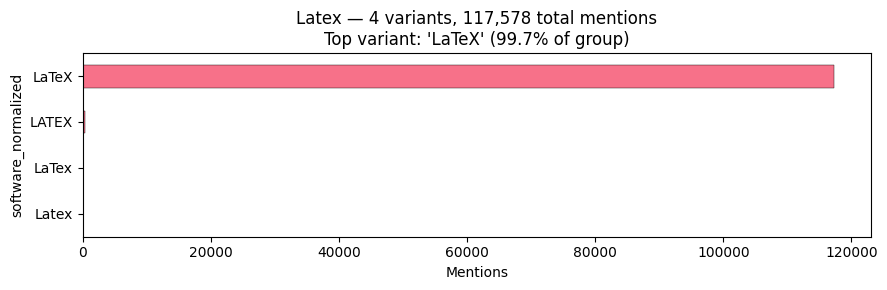

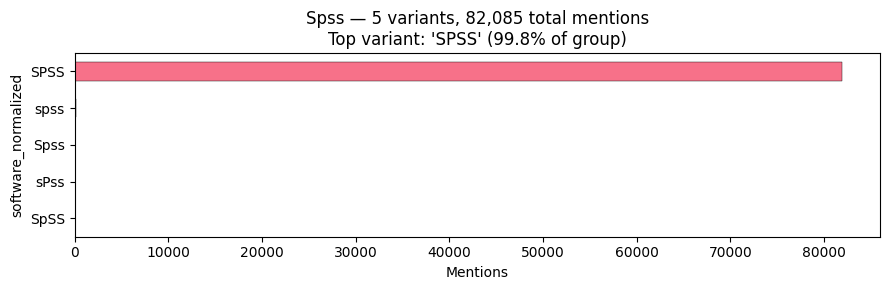

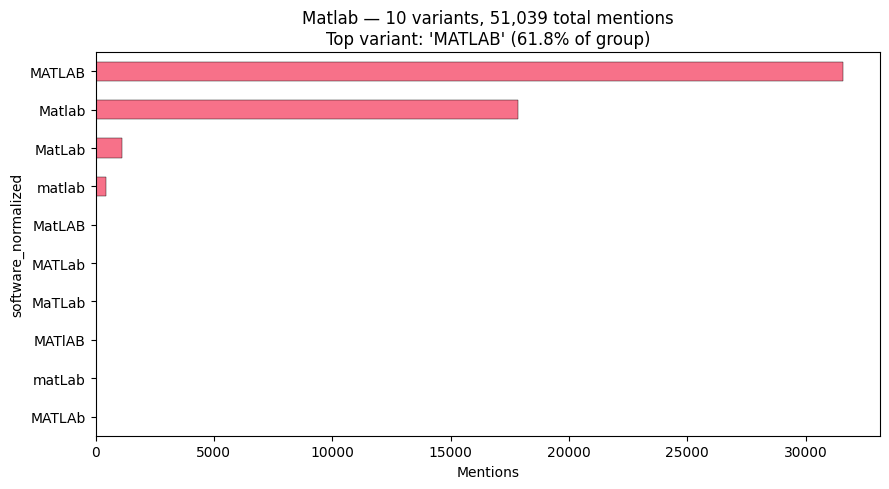

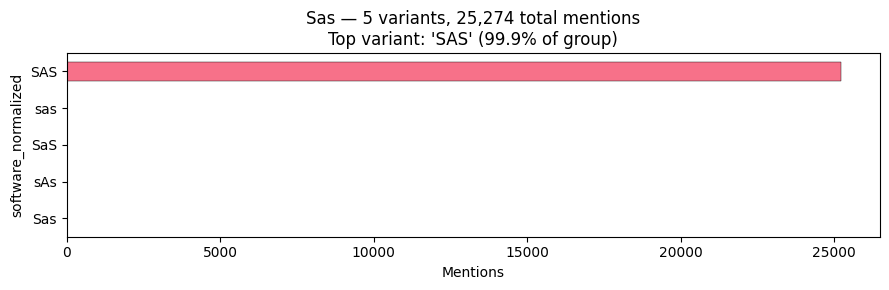

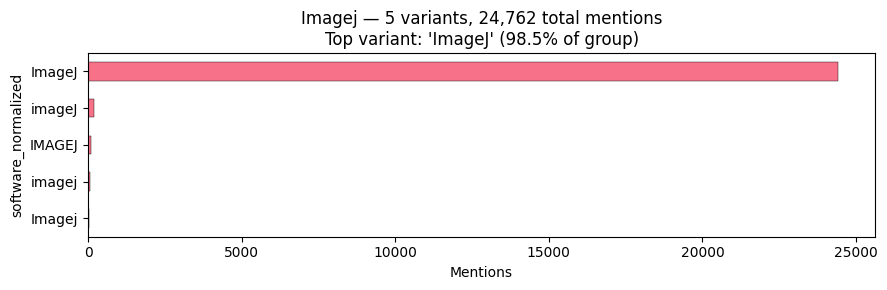

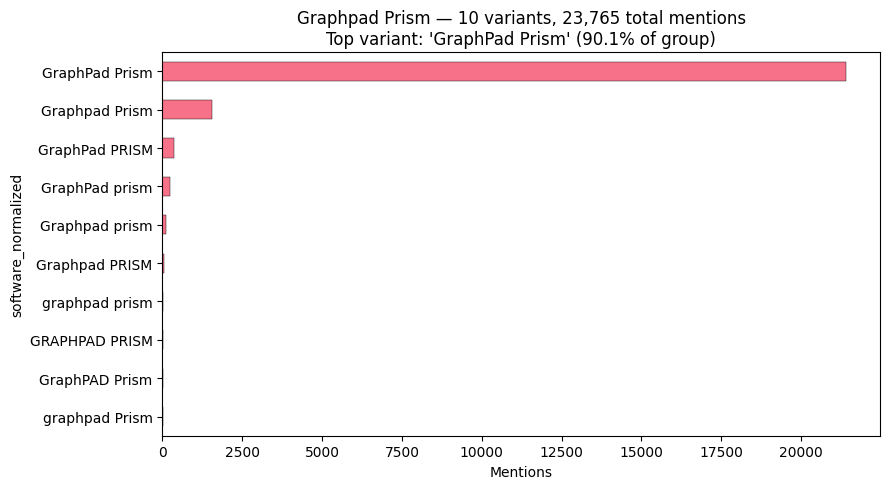

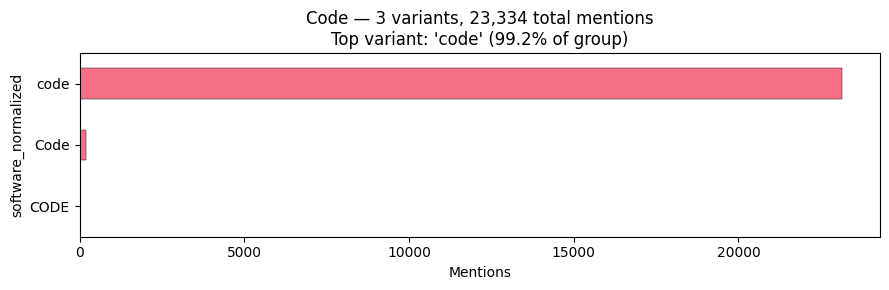

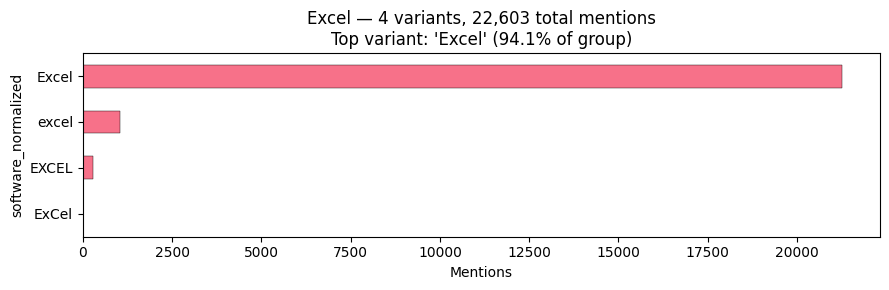

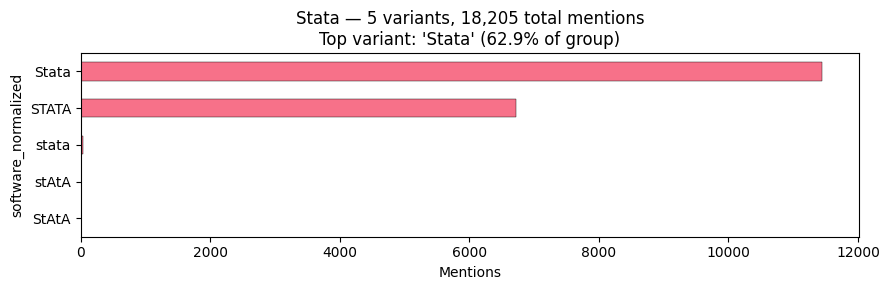

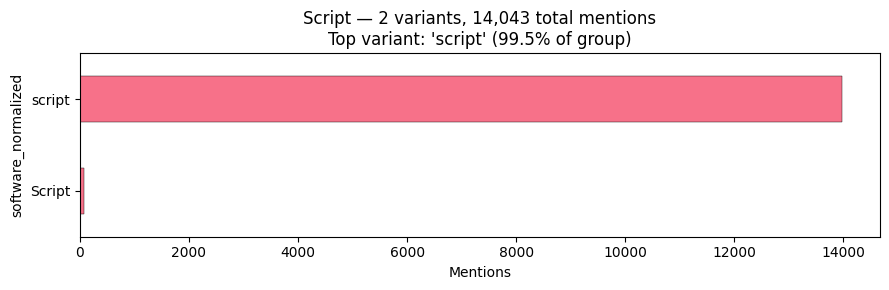

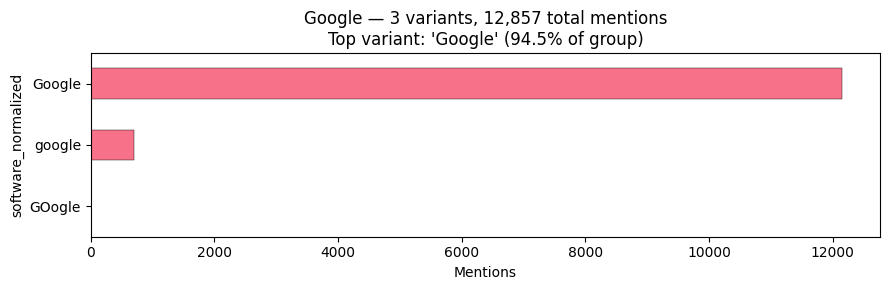

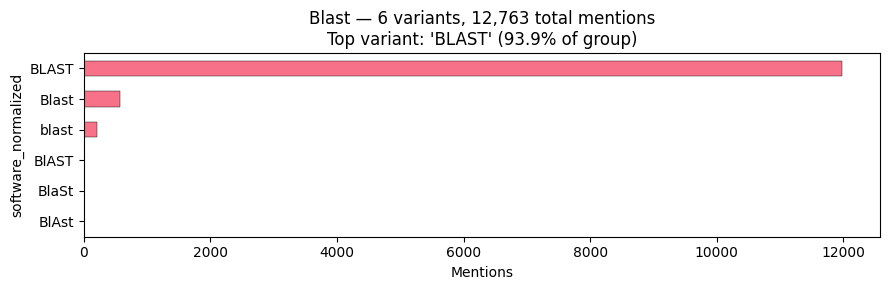

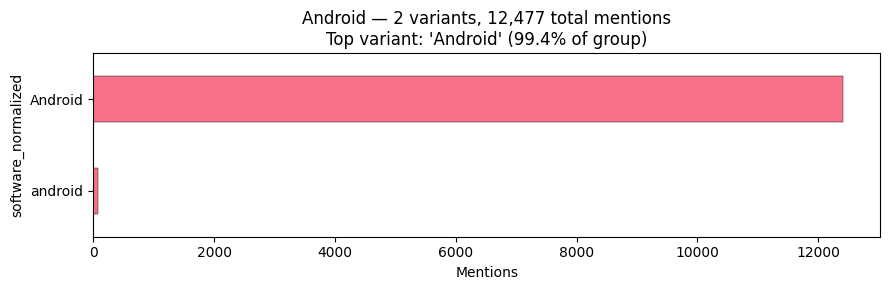

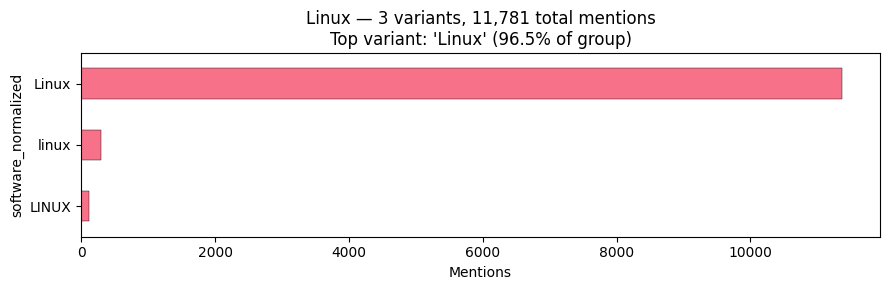

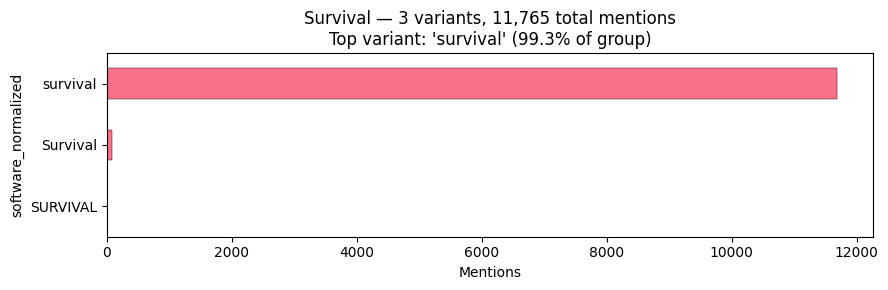

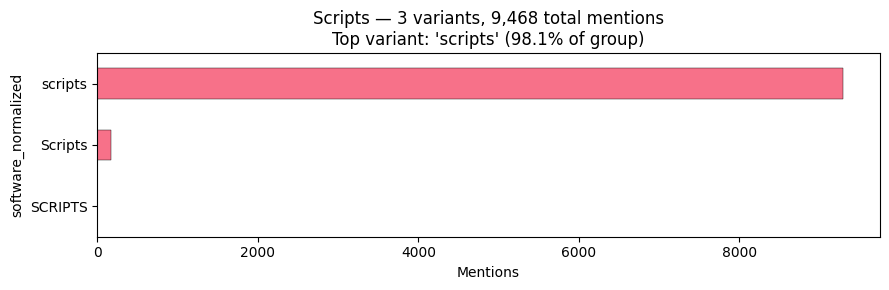

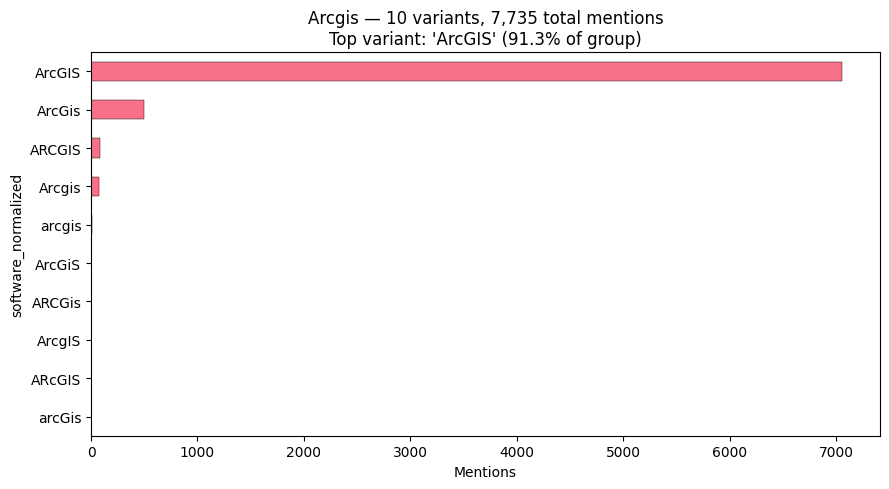

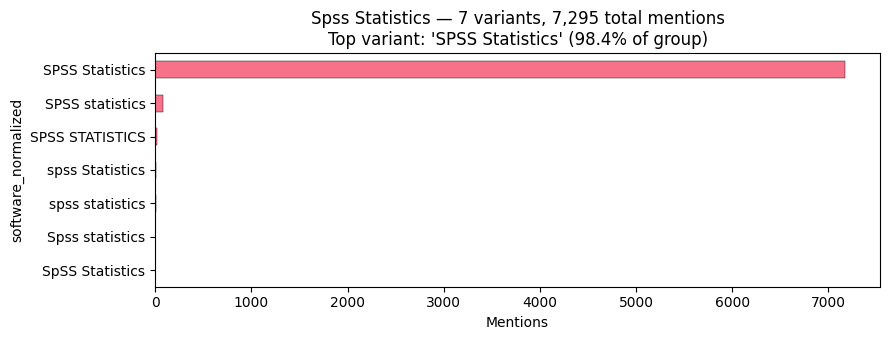

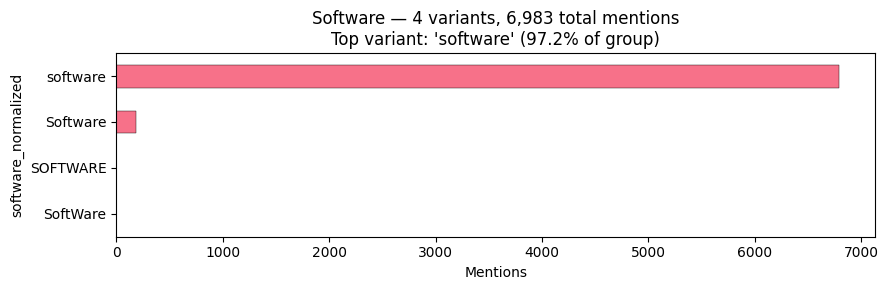

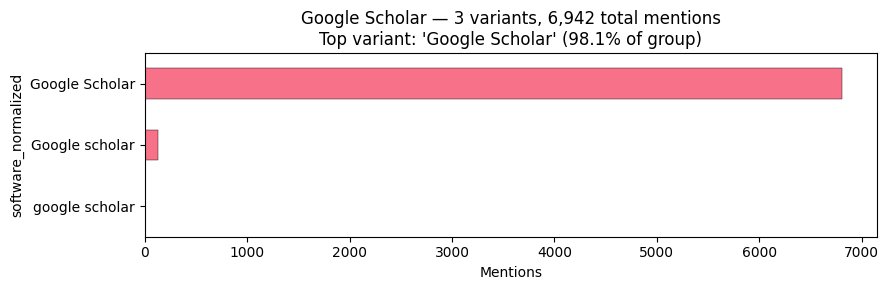

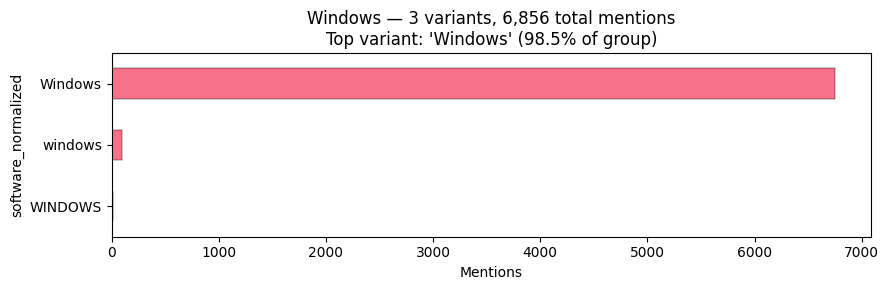

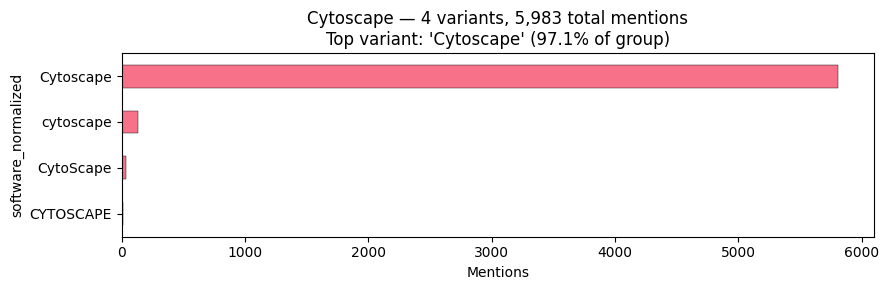

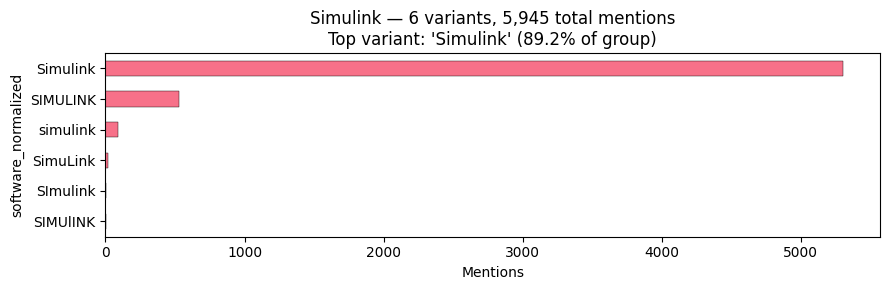

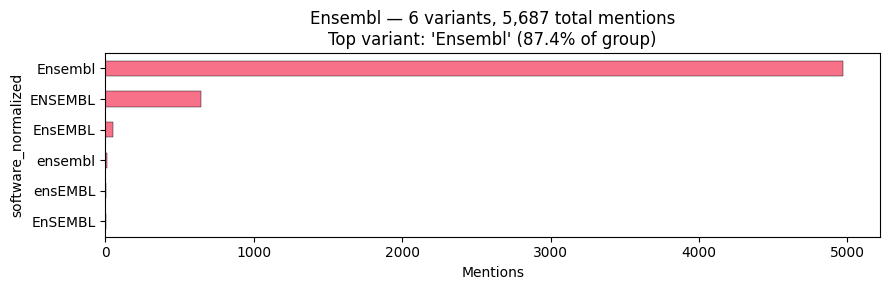

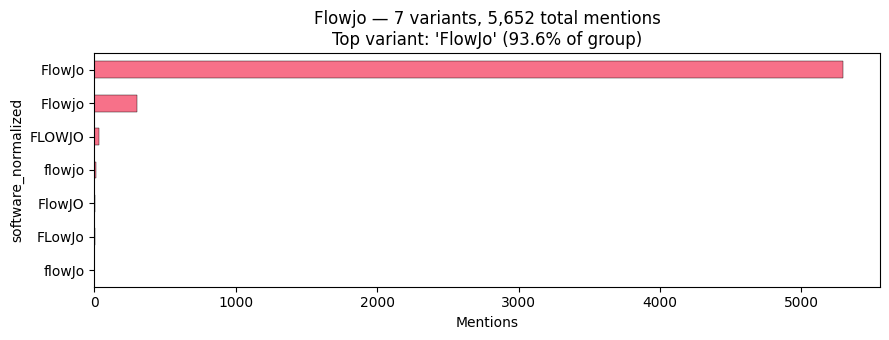

In [30]:
top_lowers = set(variants_per_software.index.tolist())
filtered = mentions_df[
    mentions_df['software_normalized'].str.lower().isin(top_lowers)
].copy()
filtered['lower'] = filtered['software_normalized'].str.lower()

for target in variants_per_software.index:
    variants = (
        filtered.loc[filtered['lower'] == target, 'software_normalized']
        .value_counts()
        .head(10)
        .sort_values(ascending=True)
    )

    fig, ax = plt.subplots(figsize=(9, max(3, len(variants) * 0.5)))
    variants.plot(kind='barh', ax=ax, edgecolor='black', linewidth=0.3)

    top_pct = variants.iloc[-1] / variants.sum() * 100
    ax.set_title(
        f"{target.title()} — {len(variants)} variants, {variants.sum():,} total mentions\n"
        f"Top variant: '{variants.index[-1]}' ({top_pct:.1f}% of group)"
    )
    ax.set_xlabel("Mentions")
    ax.set_ylabel("software_normalized")
    plt.tight_layout()
    plt.show()

### As you can see from the charts above I found that the ML model used to extract the dataset resulted in a variety of different names. These names were all the same length and mainly just differed in capitalization differences. As a result, for the rest of my analysis I will lowercase the 

Update the software_normalized to combine all of the different name variants into one single one

In [ ]:
print(len(mentions_df['software_normalized']))

mentions_df['software_normalized'] = mentions_df['software_normalized'].str.lower()

mentions_df['software_normalized'].






2777758


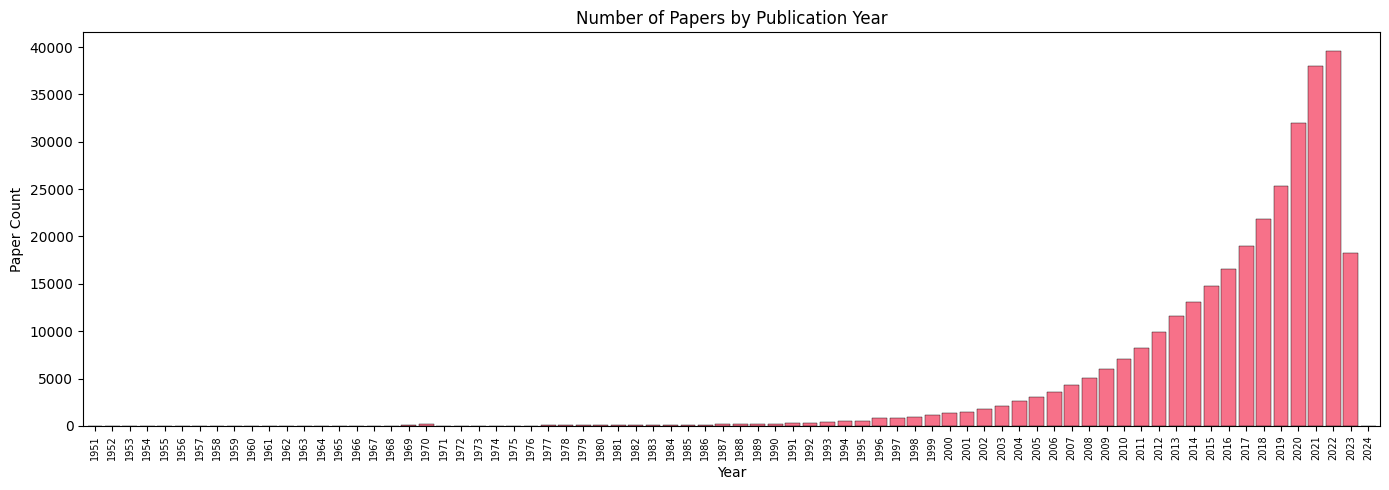

Year range: 1951 – 2024
Median year: 2018
Papers with missing year: 0


In [31]:
fig, ax = plt.subplots(figsize=(14, 5))
year_counts = papers_df['published_year'].dropna().astype(int)
year_counts = year_counts[(year_counts >= 1950) & (year_counts <= 2025)]
year_counts.value_counts().sort_index().plot(kind='bar', ax=ax, width=0.85, edgecolor='black', linewidth=0.3)
ax.set_title("Number of Papers by Publication Year")
ax.set_xlabel("Year")
ax.set_ylabel("Paper Count")
ax.tick_params(axis='x', rotation=90, labelsize=7)
plt.tight_layout()
plt.show()

print(f"Year range: {year_counts.min()} – {year_counts.max()}")
print(f"Median year: {int(year_counts.median())}")
print(f"Papers with missing year: {papers_df['published_year'].isna().sum():,}")

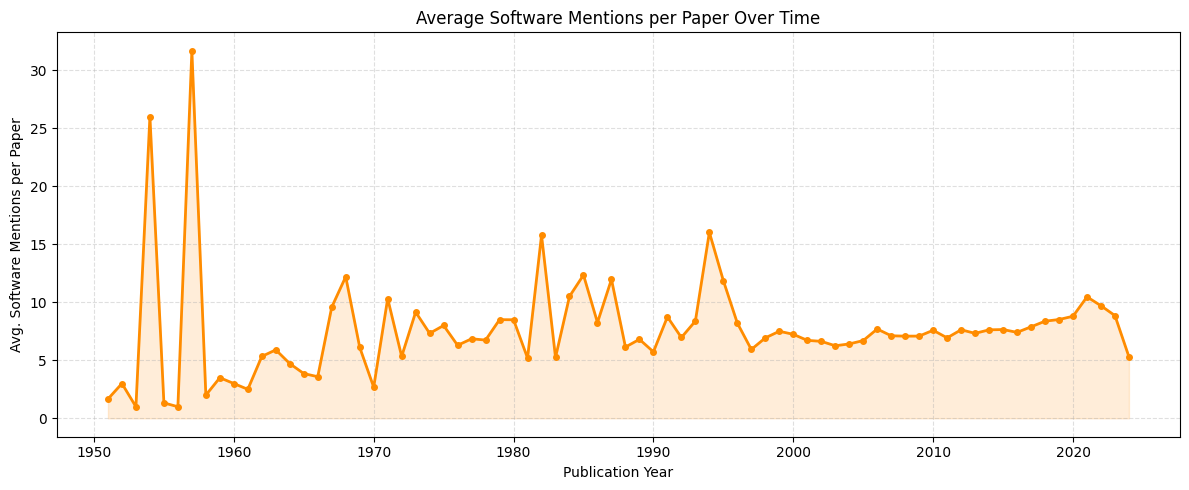

Peak year: 1957 with 31.67 mentions/paper


In [61]:
mentions_with_year = mentions_df.merge(
    papers_df[['paper_id', 'published_year']],
    on='paper_id',
    how='left'
)

year_mask = mentions_with_year['published_year'].between(1950, 2026)
paper_mask = papers_df['published_year'].between(1950, 2026)

mentions_by_year = mentions_with_year.loc[year_mask, 'published_year'].value_counts().sort_index()
papers_by_year = papers_df.loc[paper_mask, 'published_year'].value_counts().sort_index()

ratio = (mentions_by_year / papers_by_year).dropna()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(ratio.index, ratio.values, color='darkorange',
        marker='o', linewidth=2, markersize=4)
ax.fill_between(ratio.index, ratio.values, alpha=0.15, color='darkorange')

ax.set_xlabel("Publication Year")
ax.set_ylabel("Avg. Software Mentions per Paper")
ax.set_title("Average Software Mentions per Paper Over Time")
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

print(f"Peak year: {int(ratio.idxmax())} with {ratio.max():.2f} mentions/paper")

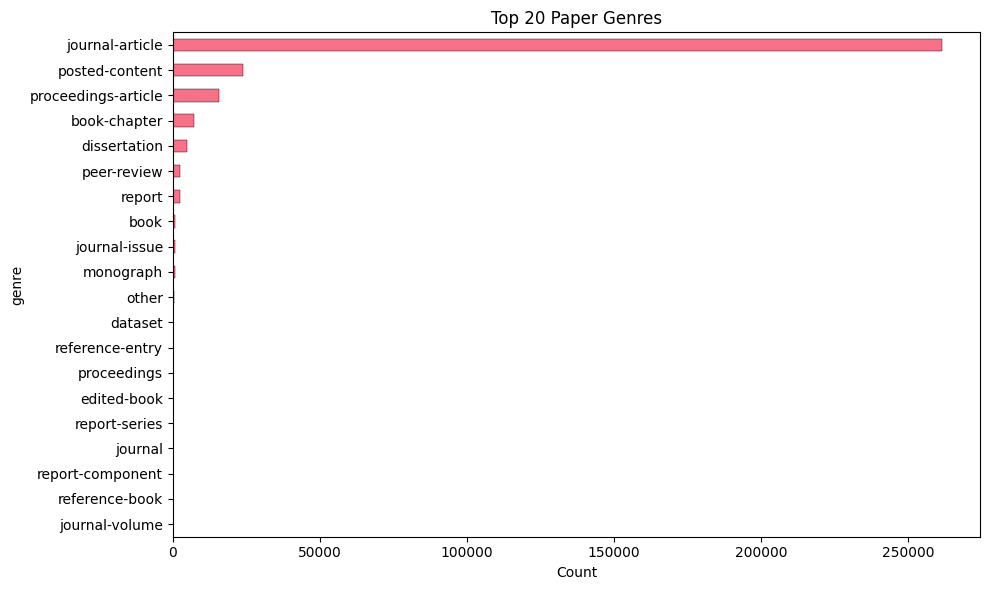

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))
papers_df['genre'].value_counts().head(20).plot(
    kind='barh', ax=ax, edgecolor='black', linewidth=0.3
)
ax.set_title("Top 20 Paper Genres")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

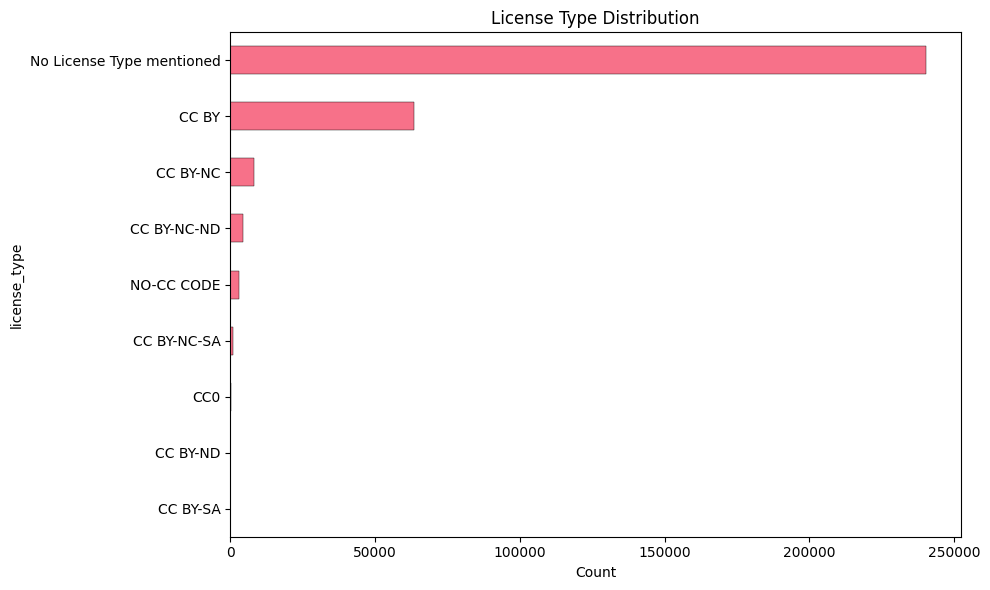

In [33]:
# Fill missing license types with "No License Type mentioned"
papers_df['license_type'] = (
    papers_df['license_type']
    .replace(r'^\s*$', pd.NA, regex=True)
    .fillna("No License Type mentioned")
)

fig, ax = plt.subplots(figsize=(10, 6))
papers_df['license_type'].value_counts().plot(
    kind='barh', ax=ax, edgecolor='black', linewidth=0.3)
ax.set_title("License Type Distribution")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

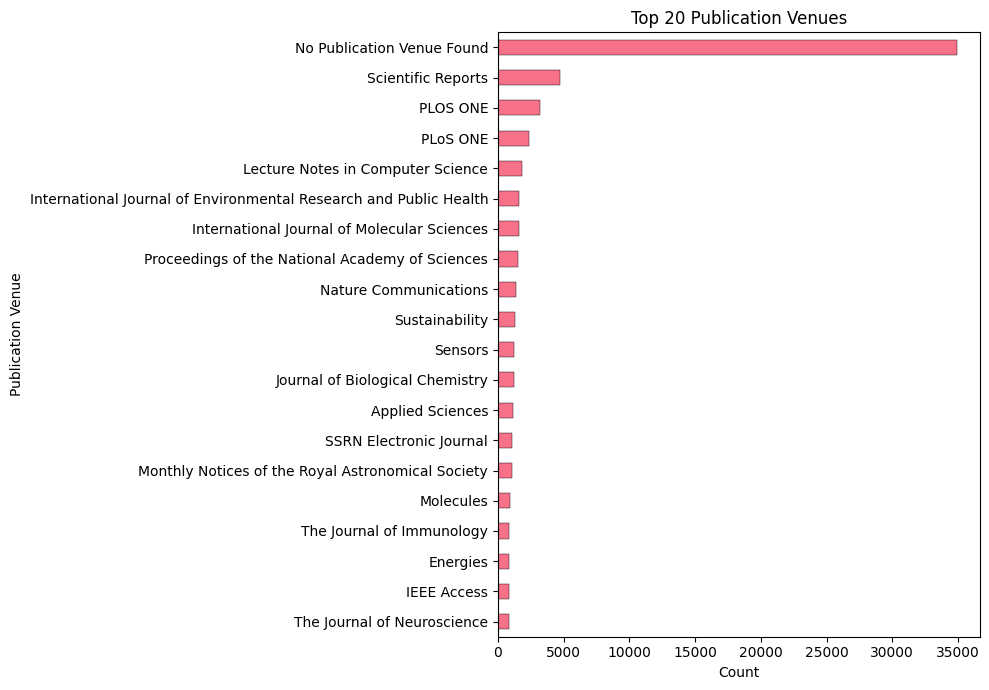

Unique venues: 45,527
Papers labeled 'No Publication Venue Found': 34,926


,publication_venue,count,percentage
0,No Publication Venue Found,34926,10.88
1,Scientific Reports,4686,1.46
2,PLOS ONE,3171,0.99
3,PLoS ONE,2353,0.73
4,Lecture Notes in Computer Science,1866,0.58
5,International Journal of Environmental Researc...,1622,0.51
6,International Journal of Molecular Sciences,1593,0.50
7,Proceedings of the National Academy of Sciences,1502,0.47
8,Nature Communications,1372,0.43
9,Sustainability,1333,0.42


In [34]:
venue_series = (
    papers_df['publication_venue']
    .replace(r'^\s*$', pd.NA, regex=True)
    .fillna("No Publication Venue Found")
)

top_venues = venue_series.value_counts().head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_venues.plot(kind='barh', ax=ax, edgecolor='black', linewidth=0.3)
ax.set_title("Top 20 Publication Venues")
ax.set_xlabel("Count")
ax.set_ylabel("Publication Venue")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

top_venues_table = (
    top_venues
    .rename_axis("publication_venue")
    .reset_index(name="count")
    .assign(percentage=lambda d: (d["count"] / len(papers_df) * 100).round(2))
)

print(f"Unique venues: {venue_series.nunique():,}")
print(f"Papers labeled 'No Publication Venue Found': "
      f"{(venue_series == 'No Publication Venue Found').sum():,}")

top_venues_table

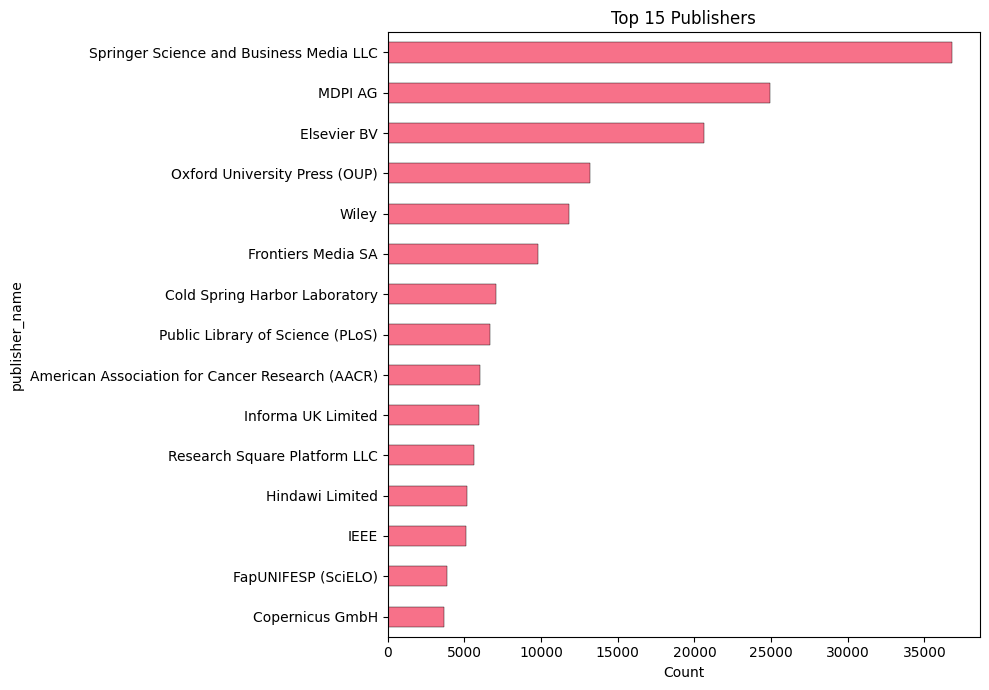

Unique publishers: 9,586
Papers where no publisher is found: 66


,publisher_name,count,share
0,Springer Science and Business Media LLC,36781,11.46
1,MDPI AG,24928,7.77
2,Elsevier BV,20640,6.43
3,Oxford University Press (OUP),13173,4.11
4,Wiley,11836,3.69
5,Frontiers Media SA,9790,3.05
6,Cold Spring Harbor Laboratory,7064,2.20
7,Public Library of Science (PLoS),6664,2.08
8,American Association for Cancer Research (AACR),5992,1.87
9,Informa UK Limited,5958,1.86


In [35]:
publisher_series = (
    papers_df['publisher_name']
    .replace(r'^\s*$', pd.NA, regex=True)
    .fillna("No Publisher Found")
)

top_publishers = publisher_series.value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 7))
top_publishers.plot(kind='barh', ax=ax, edgecolor='black', linewidth=0.3)
ax.set_title("Top 15 Publishers")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

top_publishers_table = (
    top_publishers
    .rename_axis("publisher_name")
    .reset_index(name="count")
    .assign(share=lambda d: (d["count"] / len(papers_df) * 100).round(2))
)

print(f"Unique publishers: {publisher_series.nunique():,}")
print(f"Papers where no publisher is found: "
      f"{(publisher_series == 'No Publisher Found').sum():,}")

top_publishers_table

In [ ]:
print(f"Before consolidation: {mentions_df['software_normalized'].nunique():,} unique software names")

counts = mentions_df['software_normalized'].value_counts()
counts_df = counts.rename_axis('variant').reset_index(name='n')
counts_df['key'] = counts_df['variant'].str.lower()

canonical = (
    counts_df
    .sort_values('n', ascending=False)
    .drop_duplicates(subset='key', keep='first')
    .set_index('key')['variant']
)

mentions_df['software_normalized'] = (
    mentions_df['software_normalized']
    .str.lower()
    .map(canonical)
)

print(f"After consolidation:  {mentions_df['software_normalized'].nunique():,} unique software names")
print(f"\nTop 20 after consolidation:")
mentions_df['software_normalized'].value_counts().head(20)

In [36]:
unique_software_mentions = mentions_df['software_normalized'].value_counts()
unique_software_mentions.head(20)

software_normalized
LaTeX              117252
SPSS                81880
MATLAB              31567
SAS                 25238
ImageJ              24401
code                23140
GraphPad Prism      21401
Excel               21265
Matlab              17829
script              13971
Android             12403
Google              12155
BLAST               11983
survival            11681
Stata               11449
Linux               11369
scripts              9286
SPSS Statistics      7177
ArcGIS               7059
Google Scholar       6807
Name: count, dtype: int64

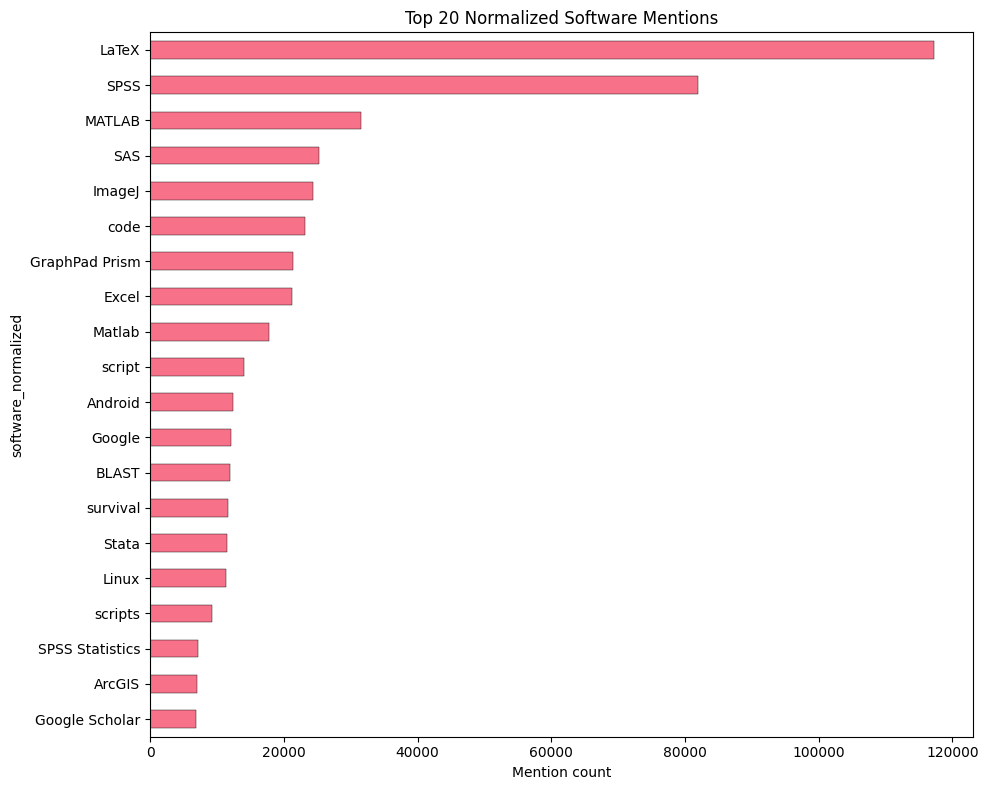

In [37]:
counts = mentions_df['software_normalized'].value_counts().head(20)
fig, ax = plt.subplots(figsize=(10, 8))
counts.plot(kind="barh", ax=ax, edgecolor="black", linewidth=0.3)
ax.set_title(f"Top {20} Normalized Software Mentions")
ax.set_xlabel("Mention count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [38]:
# Count mentions per paper
mentions_per_paper = mentions_df.groupby('paper_id').size().reset_index(name='mention_count')

# Show distribution of mentions per paper
print(f"\nMention count statistics:")
print(mentions_per_paper['mention_count'].describe())

# Show papers with most mentions
print(f"\nTop 20 papers by mention count:")
top_papers = mentions_per_paper.nlargest(20, 'mention_count')
print(top_papers)



Mention count statistics:
count    320866.000000
mean          8.657066
std          63.302443
min           1.000000
25%           1.000000
50%           2.000000
75%           6.000000
max       32162.000000
Name: mention_count, dtype: float64

Top 20 papers by mention count:
        paper_id  mention_count
125535   9286192          32162
128204   9485442           3585
274699  20323662           3148
146310  10830805           3063
297591  22031951           2690
34786    2567414           2417
292229  21627864           1619
74901    5535986           1616
290172  21472294           1575
21163    1564995           1343
222235  16462385           1271
29175    2146144           1270
137177  10160346           1260
209129  15488848           1248
72495    5354066           1197
166532  12345743           1177
70795    5229009           1155
227367  16837963           1118
105729   7821710           1057
486        36181           1034


In [39]:
def plot_software_mentions_for_paper(paper_id, top_n=10, figsize=(12, 6), color='skyblue'):
    """
    Create a bar chart showing the top software mentions for a specific paper.
    
    Parameters:
    -----------
    paper_id : int
        The paper ID to analyze
    top_n : int, default 10
        Number of top software to display
    figsize : tuple, default (12, 6)
        Figure size for the plot
    color : str, default 'skyblue'
        Color for the bars
    
    Returns:
    --------
    matplotlib.figure.Figure
        The created figure object
    """
    # Get the paper info
    paper_info = papers_df[papers_df['paper_id'] == paper_id]
    if len(paper_info) == 0:
        print(f"No paper found with ID {paper_id}")
        return None
    
    # Get software mentions for this paper
    paper_mentions = mentions_df[mentions_df['paper_id'] == paper_id]
    if len(paper_mentions) == 0:
        print(f"No software mentions found for paper {paper_id}")
        return None
    
    # Count mentions by software
    mention_counts = paper_mentions['software_normalized'].value_counts()
    
    # Get top N software
    top_n_mentions = mention_counts.head(top_n)
    
    # Convert to DataFrame for plotting
    plot_df = top_n_mentions.reset_index()
    plot_df.columns = ['Software', 'Mentions']
    
    # Create the plot
    plt.figure(figsize=figsize)
    bars = plt.bar(plot_df['Software'], plot_df['Mentions'], color=color)
    
    # Add labels and title
    paper_title = paper_info['title'].iloc[0] if 'title' in paper_info.columns else f"Paper {paper_id}"
    paper_title = str(paper_title).replace('$', r'\$')
    plt.title(f'Top Software Mentions found in {paper_title} ({paper_info["published_year"].iloc[0]})') 
    plt.xlabel('Software Name')
    plt.ylabel('Number of Mentions')
    
    # Rotate x-axis labels
    plt.xticks(rotation=45, ha='right')
    
    # Add value labels on bars
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, 
                 int(yval), ha='center', va='bottom', fontsize=10)
    
    # Add grid and adjust layout
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()

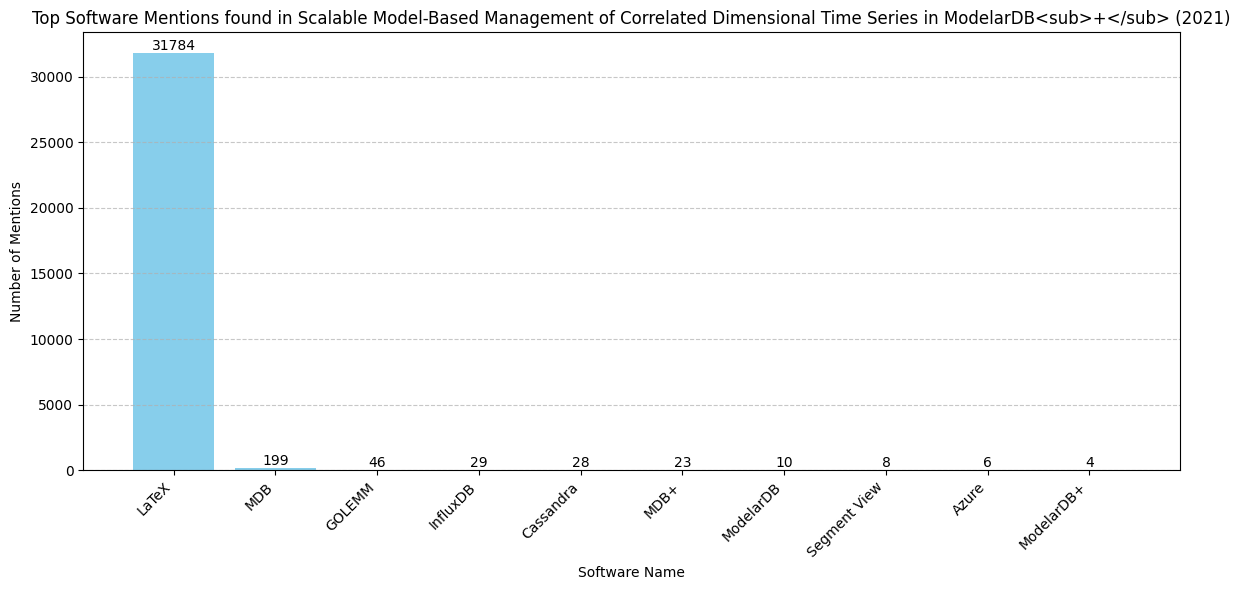

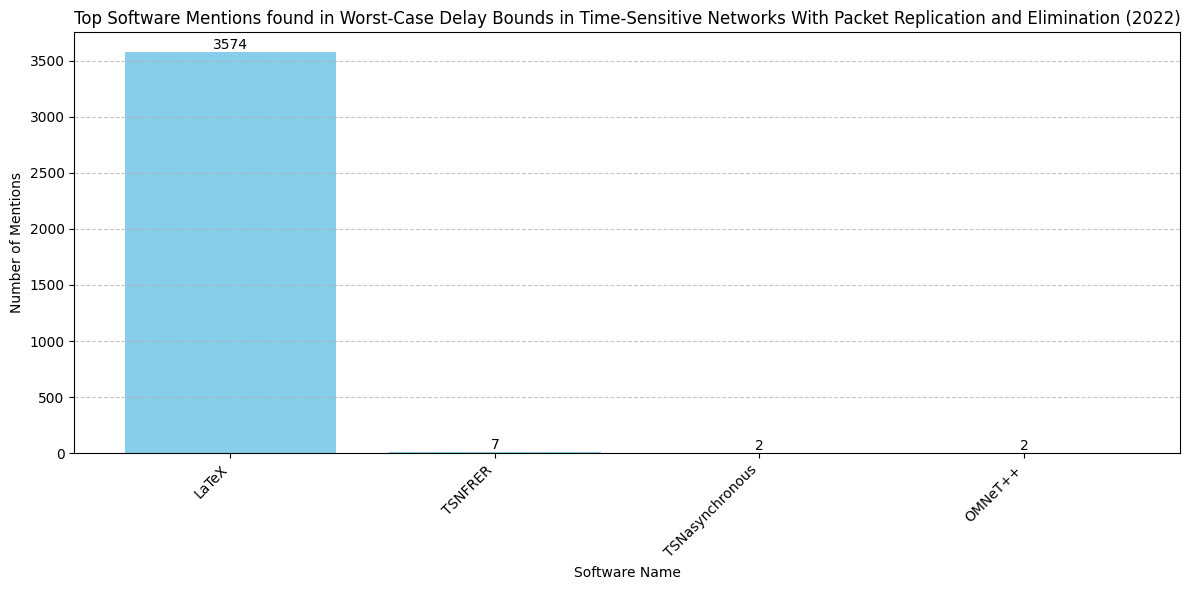

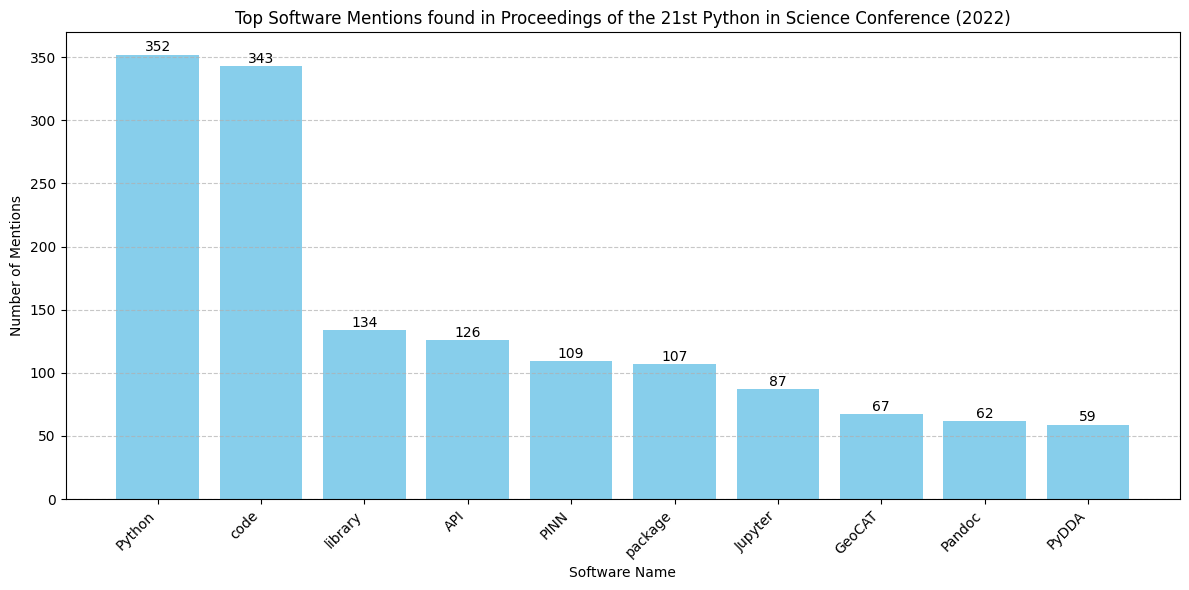

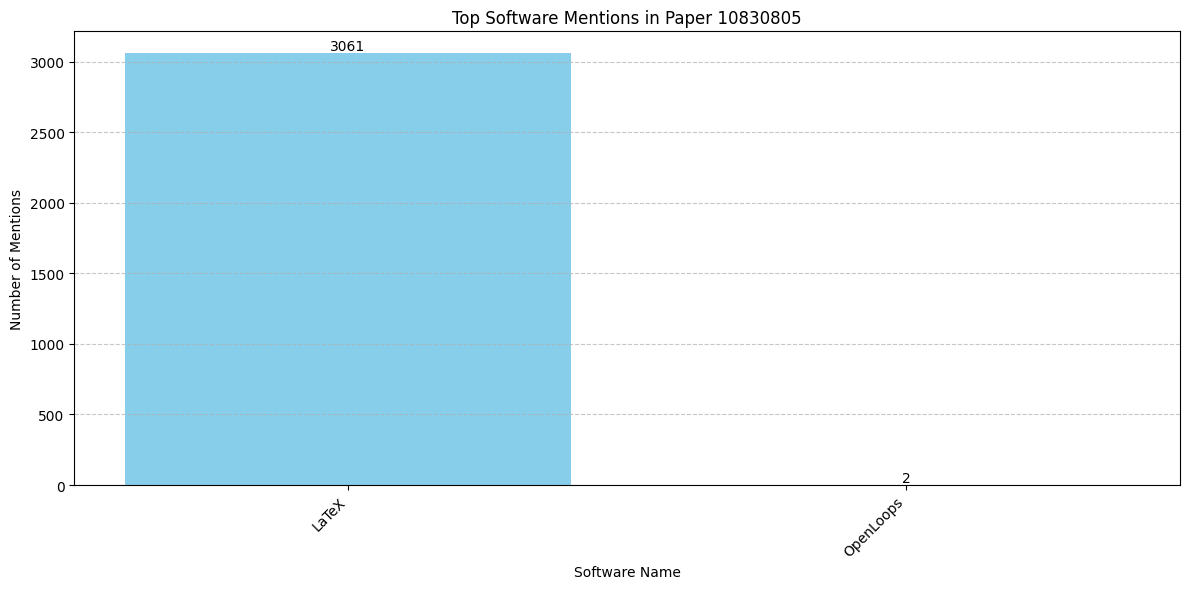

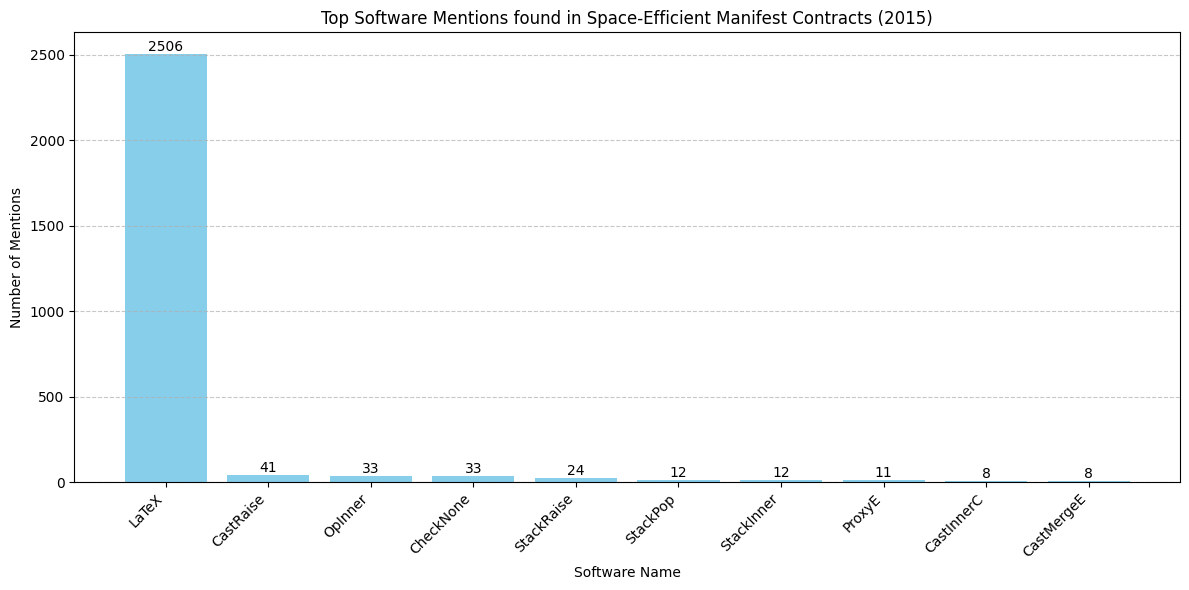

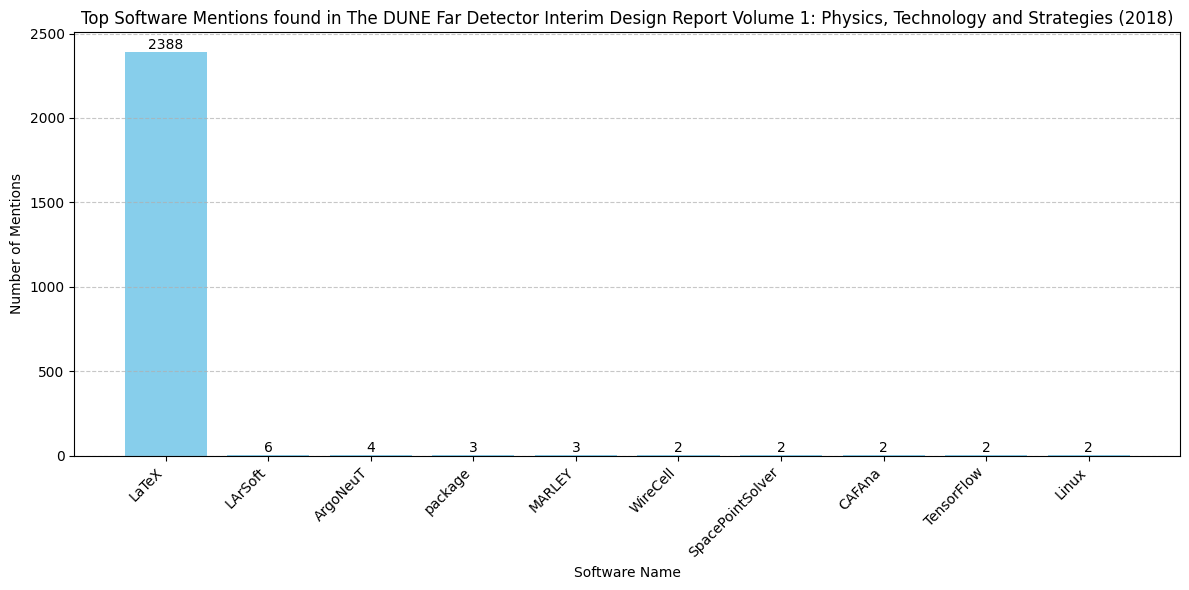

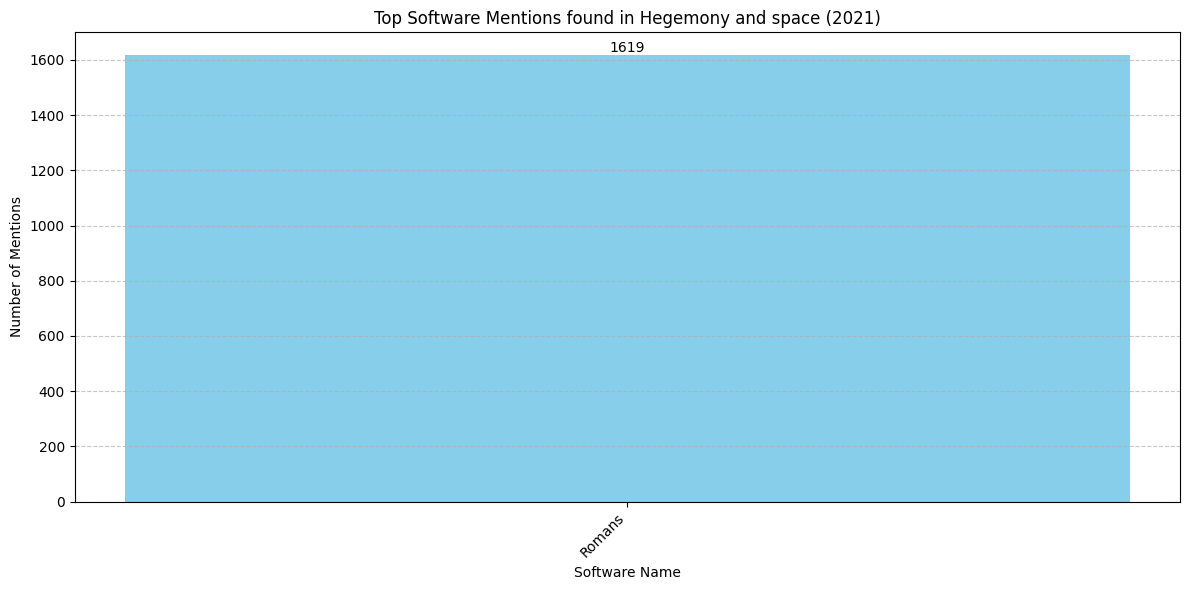

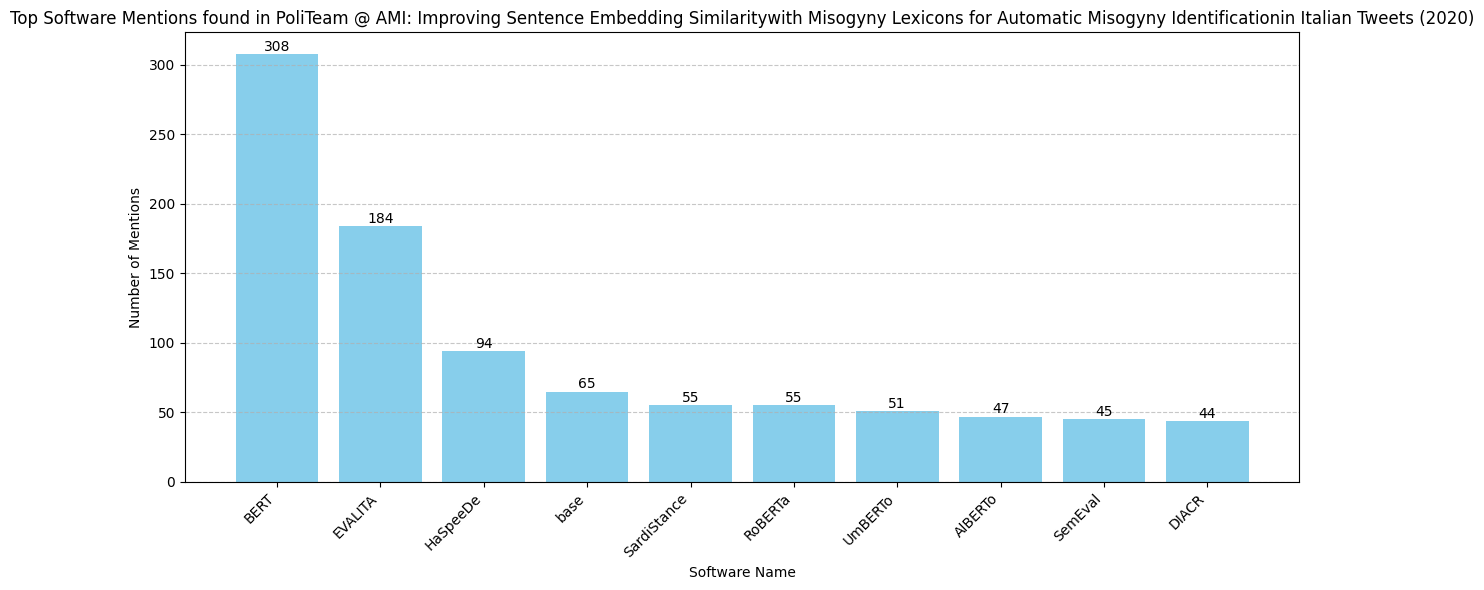

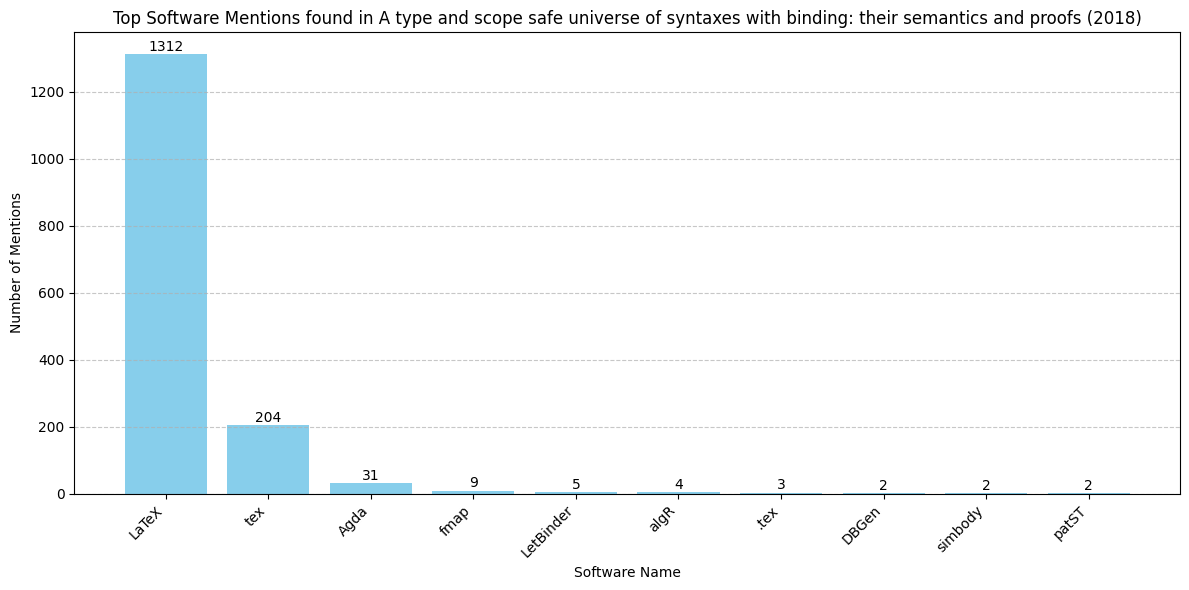

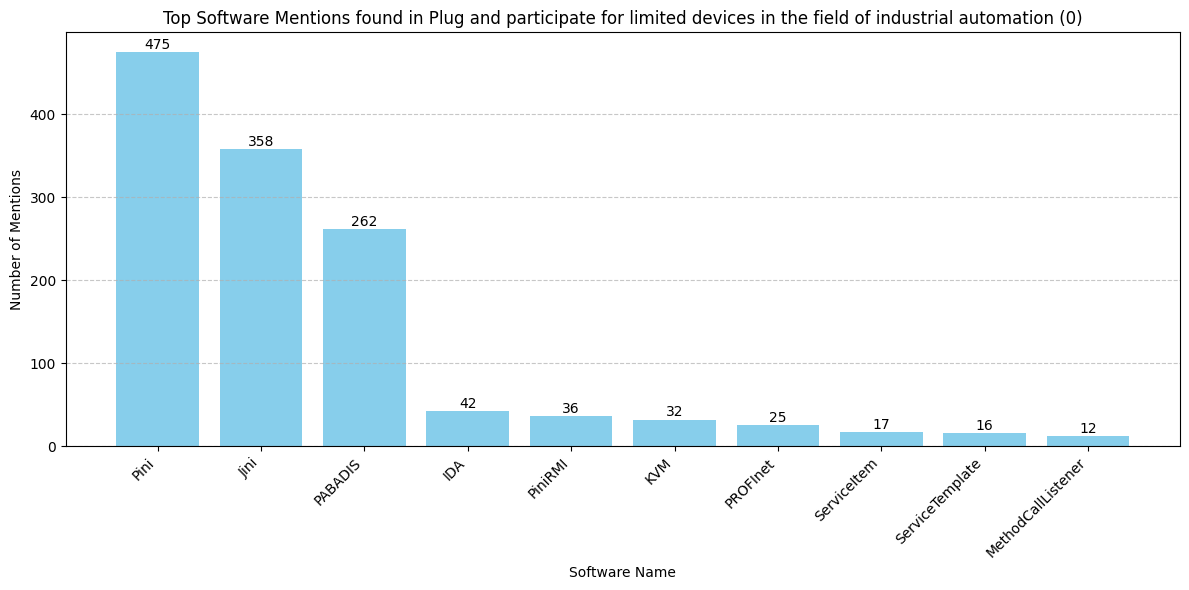

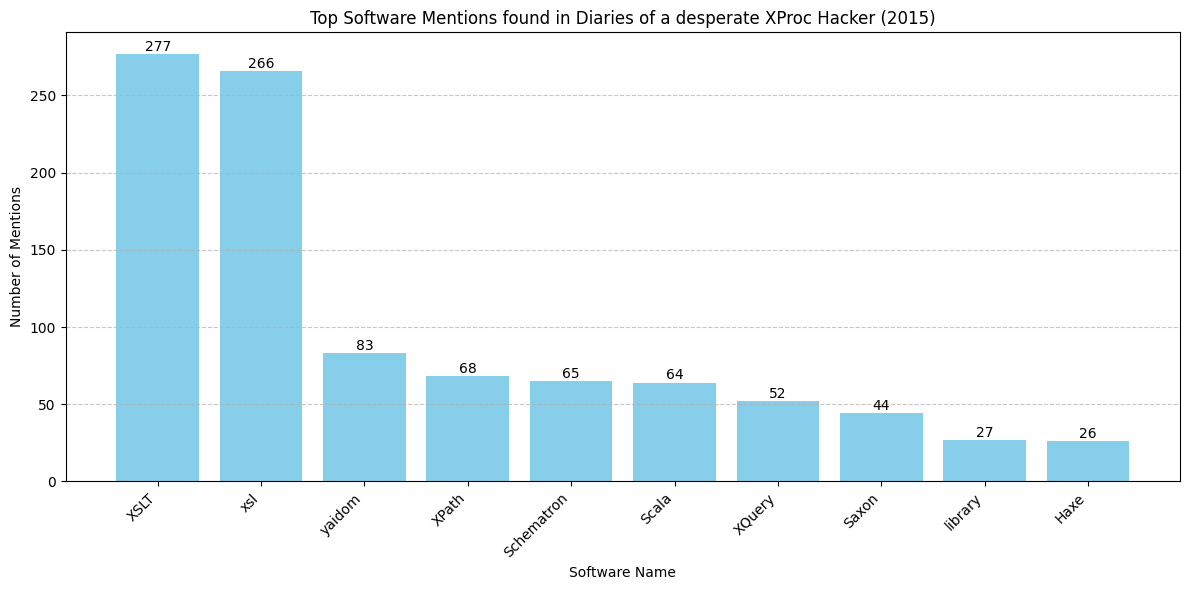

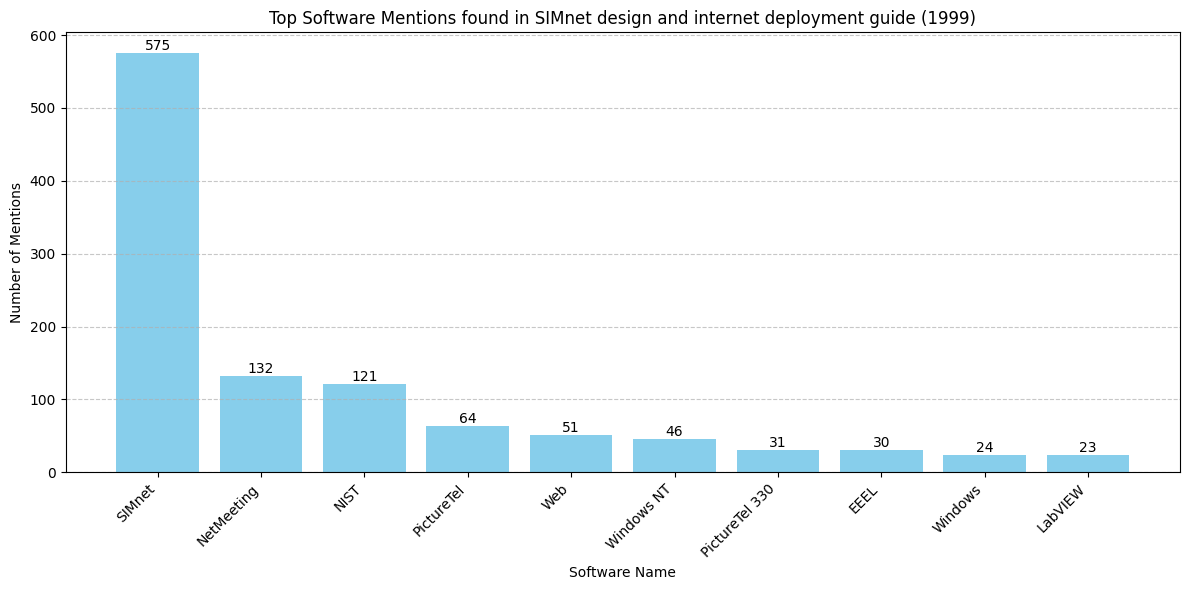

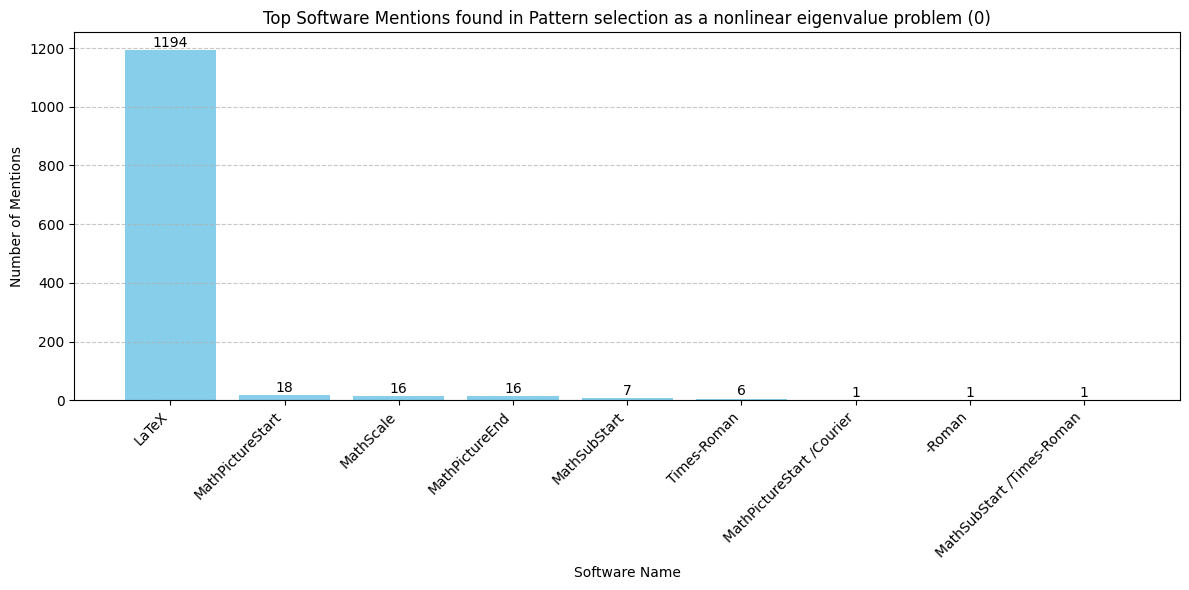

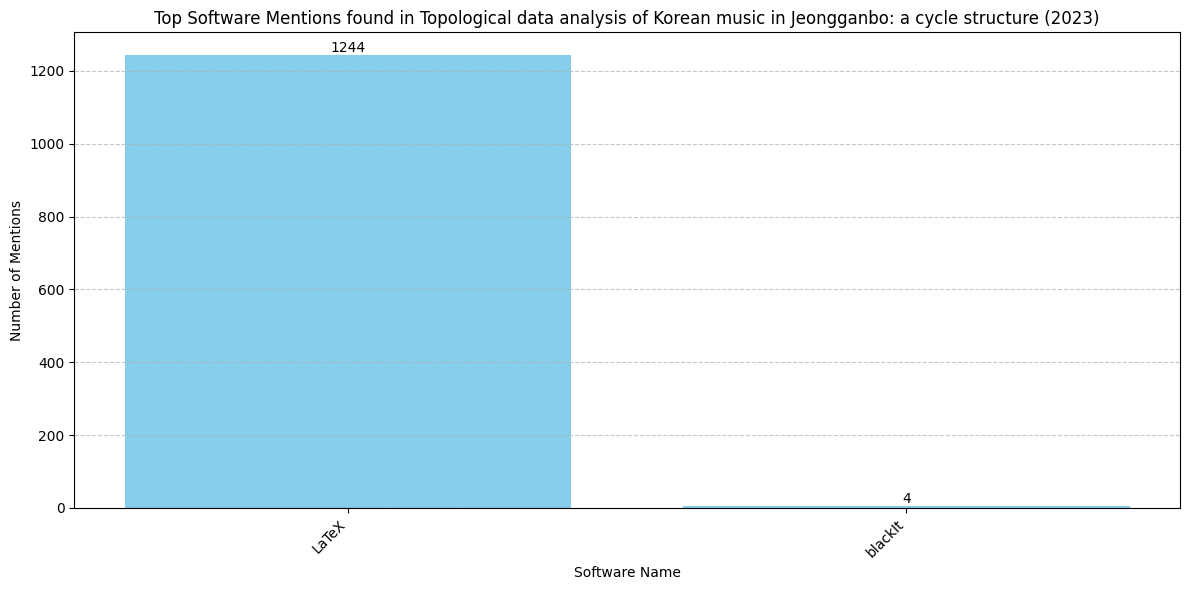

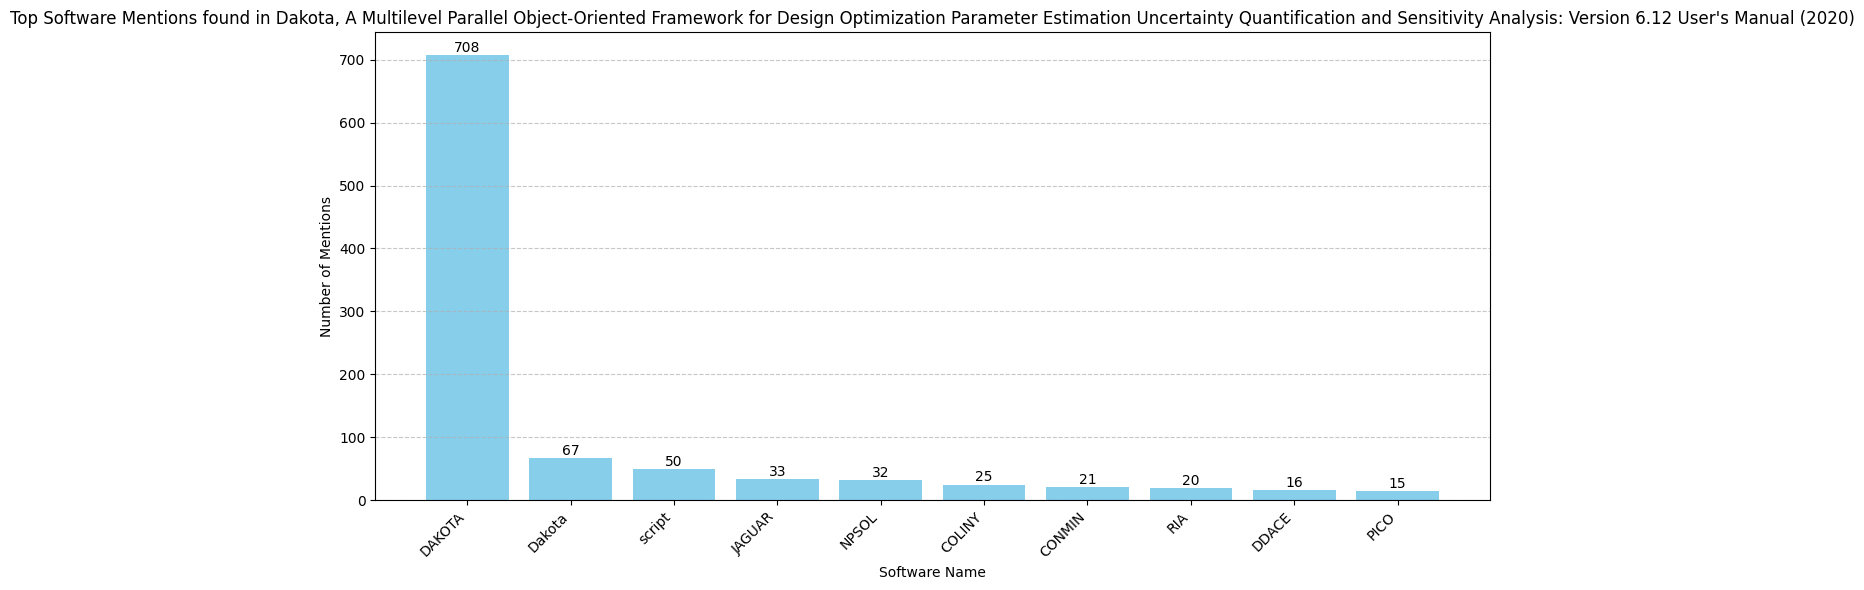

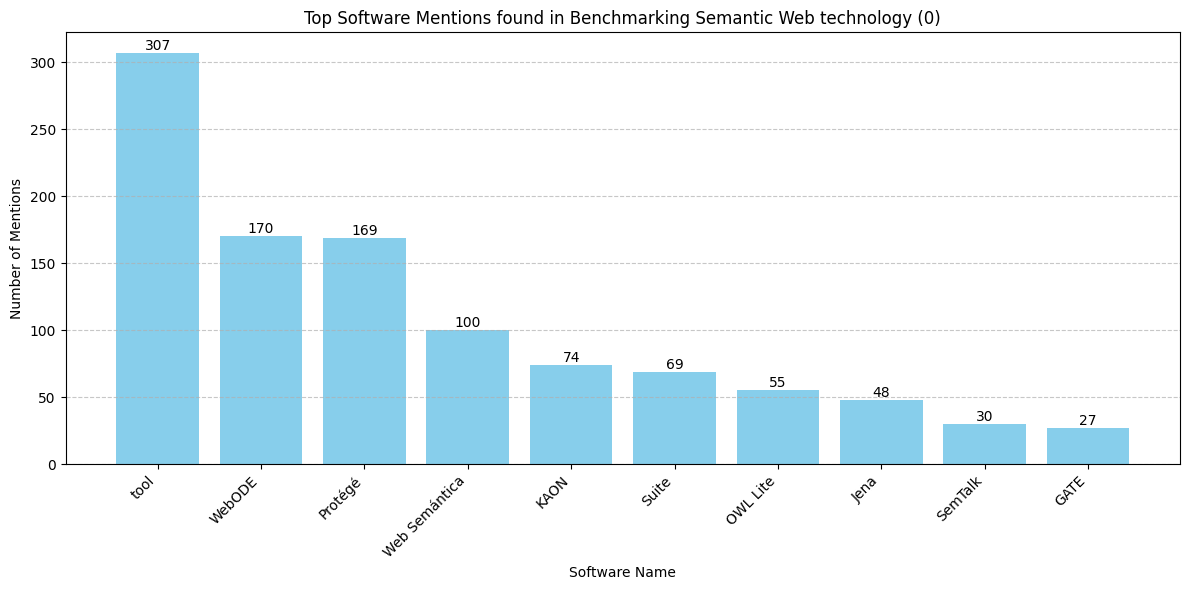

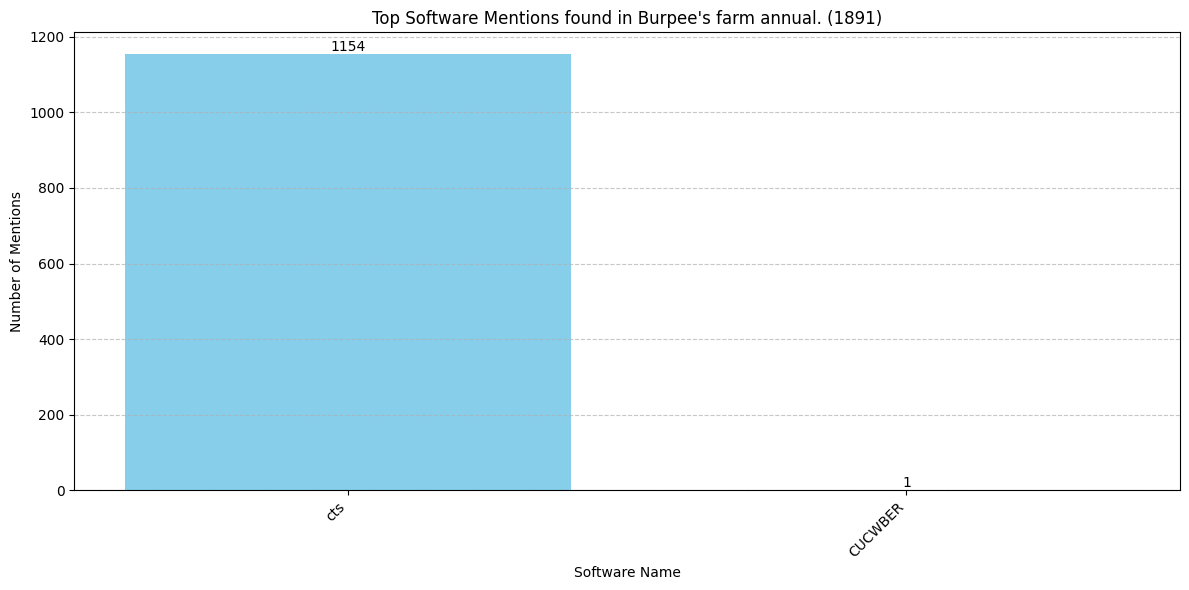

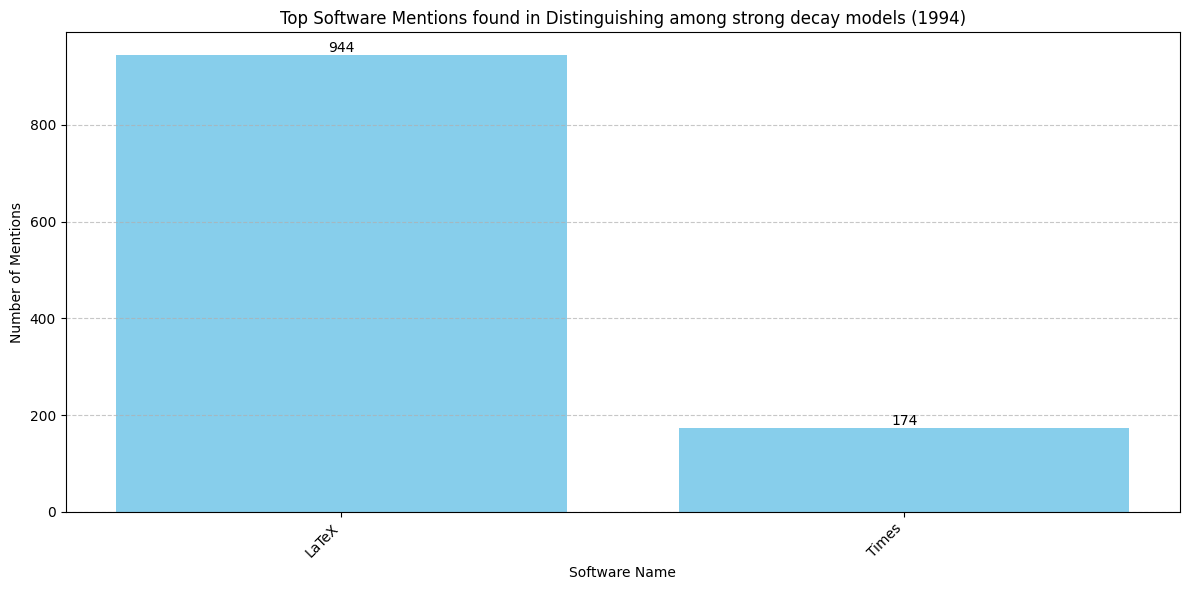

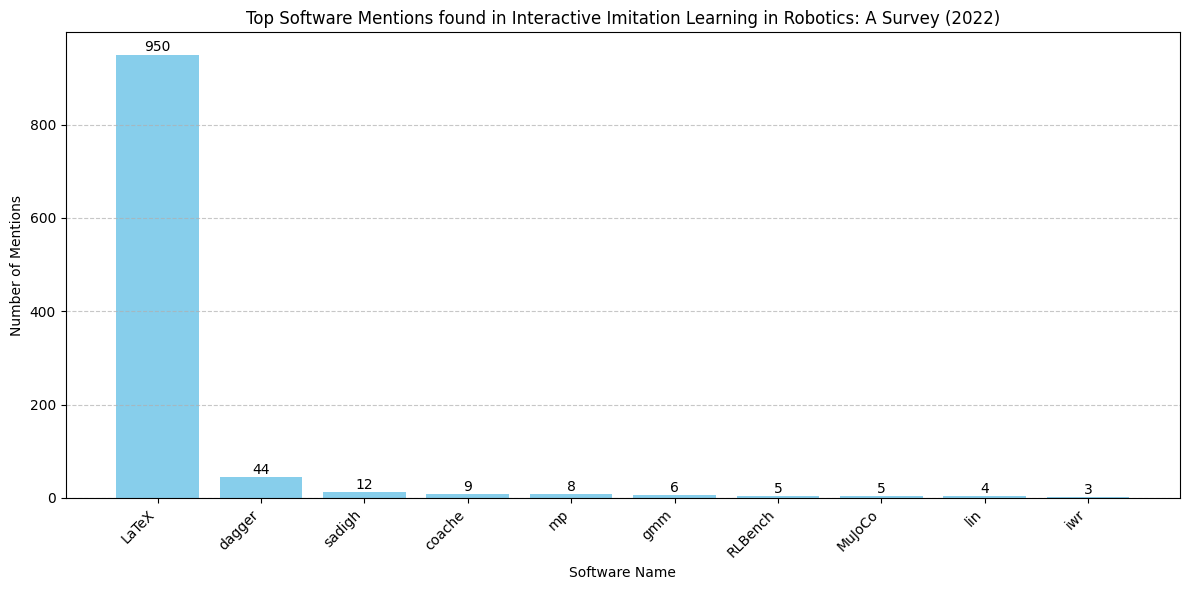

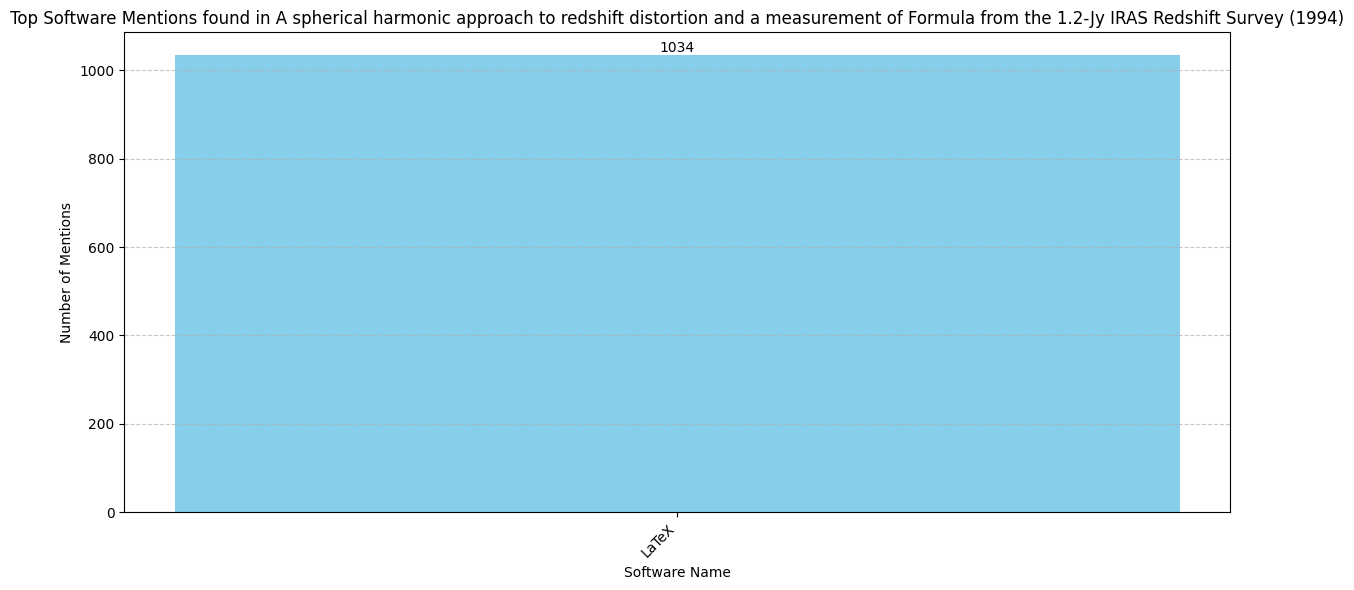

In [40]:
# Top 20 papers by total mention count
top20_paper_ids = (
    mentions_df.groupby('paper_id')
    .size()
    .sort_values(ascending=False)
    .head(20)
    .index
)

bad_paper_id = 10830805

for pid in top20_paper_ids:
    if pid == bad_paper_id:
        # temporary override: no full title
        plot_software_mentions_for_paper(pid, top_n=10)
        plt.title(f"Top Software Mentions in Paper {pid}")  # overwrite long title
        plt.tight_layout()
        plt.show()
    else:
        plot_software_mentions_for_paper(pid, top_n=10)
        plt.show()

In [41]:
raw_per_normalized = (
    mentions_df.groupby('software_normalized')['software_raw']
    .nunique()
    .sort_values(ascending=False)
)
print("Normalized names with the most distinct raw variants:")
print(raw_per_normalized.head(15))

print(f"\nTotal unique raw software names: {mentions_df['software_raw'].nunique():,}")
print(f"Total unique normalized software names: {mentions_df['software_normalized'].nunique():,}")

Normalized names with the most distinct raw variants:
software_normalized
Statistical Package for the Social Sciences           21
Statistical Package for the Social Sciences (SPSS)    21
Vienna ab initio simulation package (VASP)            19
Statistical Package for Social Sciences               18
Basic Local Alignment Search Tool (BLAST)             17
Statistical Package for the Social Sciences (SPSS     16
Statistical Package for Social Science (SPSS)         14
Vienna Ab initio Simulation Package (VASP)            13
Statistical Package for Social Sciences (SPSS         13
Statistical Package for the Social Science (SPSS)     13
SPSS (Statistical Package for the Social Sciences)    12
Ingenuity Pathway Analysis                            12
CLC Genomics Workbench                                12
Google Scholar                                        11
Vienna Ab Initio Simulation Package (VASP)            10
Name: software_raw, dtype: int64

Total unique raw software names: 234,

In [42]:
# Count mentions by normalized software
software_counts = mentions_df['software_normalized'].value_counts().head(20)
print("Top 20 most mentioned software:")
print(software_counts)

Top 20 most mentioned software:
software_normalized
LaTeX              117252
SPSS                81880
MATLAB              31567
SAS                 25238
ImageJ              24401
code                23140
GraphPad Prism      21401
Excel               21265
Matlab              17829
script              13971
Android             12403
Google              12155
BLAST               11983
survival            11681
Stata               11449
Linux               11369
scripts              9286
SPSS Statistics      7177
ArcGIS               7059
Google Scholar       6807
Name: count, dtype: int64


In [43]:
# Function to analyze specific software mentions
def analyze_software_mentions(software_name, use_normalized=True):
    """
    Analyze mentions of a specific software across papers
    """
    if use_normalized:
        software_mentions = mentions_df[mentions_df['software_normalized'] == software_name]
    else:
        software_mentions = mentions_df[mentions_df['software_raw'] == software_name]
    
    if len(software_mentions) == 0:
        print(f"No mentions found for '{software_name}'")
        return None
    
    # Count mentions per paper for this software
    mentions_by_paper = software_mentions.groupby('paper_id').size().reset_index(name='mention_count')
    
    print(f"Analysis for '{software_name}'")
    print(f"Total mentions: {len(software_mentions):,}")
    print(f"Number of papers mentioning it: {len(mentions_by_paper):,}")
    print(f"Average mentions per paper: {mentions_by_paper['mention_count'].mean():.2f}")
    print(f"Max mentions in a single paper: {mentions_by_paper['mention_count'].max()}")
    
    # Show papers with most mentions of this software
    print(f"\nPapers with most mentions of '{software_name}':")
    top_papers = mentions_by_paper.nlargest(10, 'mention_count')
    print(top_papers)
    
    return mentions_by_paper

In [44]:
top20_software = (
    mentions_df['software_normalized']
    .dropna()
    .value_counts()
    .head(20)
    .index
)

results = {}
for name in top20_software:
    print("\n" + "=" * 60)
    results[name] = analyze_software_mentions(name)


Analysis for 'LaTeX'
Total mentions: 117,252
Number of papers mentioning it: 1,034
Average mentions per paper: 113.40
Max mentions in a single paper: 31784

Papers with most mentions of 'LaTeX':
     paper_id  mention_count
395   9286192          31784
405   9485442           3574
464  10830805           3061
962  22031951           2506
93    2567414           2388
939  21472294           1312
666  15488848           1244
436  10160346           1194
1       36181           1034
645  14771354            956

Analysis for 'SPSS'
Total mentions: 81,880
Number of papers mentioning it: 51,587
Average mentions per paper: 1.59
Max mentions in a single paper: 103

Papers with most mentions of 'SPSS':
       paper_id  mention_count
31162  14395426            103
32014  14789470             47
26665  12330291             44
6129    2832969             43
23161  10663558             41
21509   9912488             36
15568   7154195             34
4105    1881324             30
45428  20933797 

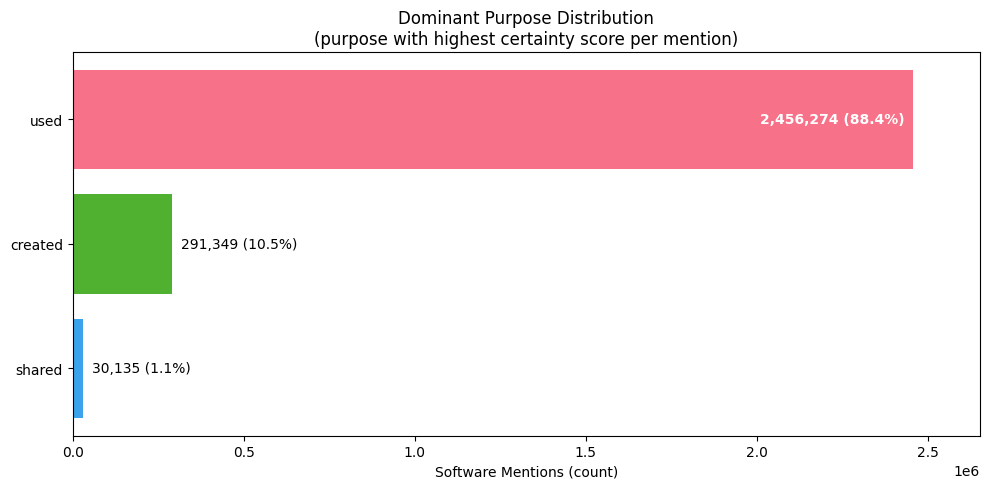

           count    pct
purpose                
used     2456274  88.43
created   291349  10.49
shared     30135   1.08


In [49]:
dominant_purpose = (
    purpose_df.loc[purpose_df.groupby('software_mention_id')['certainty_score'].idxmax()]
    [['software_mention_id', 'purpose', 'certainty_score']]
)

purpose_counts = dominant_purpose['purpose'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(purpose_counts.index, purpose_counts.values,
               color=sns.color_palette("husl", len(purpose_counts)))
ax.set_xlabel("Software Mentions (count)")
ax.set_title("Dominant Purpose Distribution\n(purpose with highest certainty score per mention)")
ax.invert_yaxis()

max_val = purpose_counts.max()
ax.set_xlim(0, max_val * 1.08)  # a bit of breathing room on the right

for bar, val in zip(bars, purpose_counts.values):
    label = f"{val:,} ({val/len(dominant_purpose)*100:.1f}%)"
    if val / max_val > 0.6:
        # Long bar: put label inside, right-aligned, white text
        ax.text(bar.get_width() - max_val * 0.01,
                bar.get_y() + bar.get_height() / 2,
                label, va='center', ha='right',
                fontsize=10, color='white', fontweight='bold')
    else:
        # Short bar: keep label outside
        ax.text(bar.get_width() + max_val * 0.01,
                bar.get_y() + bar.get_height() / 2,
                label, va='center', ha='left', fontsize=10)

plt.tight_layout()
plt.show()

print(purpose_counts.to_frame("count")
      .assign(pct=lambda d: (d["count"] / len(dominant_purpose) * 100).round(2)))

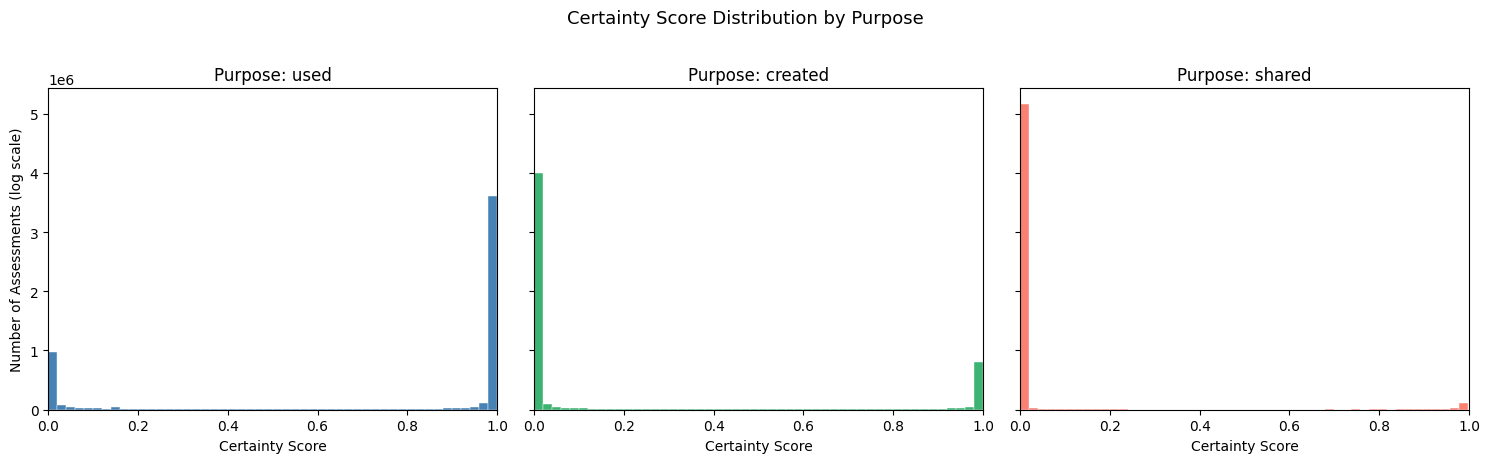


Certainty score summary stats by purpose:
             count   mean    std  min    25%  50%    75%    max
purpose                                                        
used     5555516.0  0.736  0.415  0.0  0.327  1.0  1.000  1.000
created  5555516.0  0.205  0.381  0.0  0.000  0.0  0.074  1.000
shared   5555516.0  0.044  0.189  0.0  0.000  0.0  0.000  0.998


In [54]:
purposes = ['used', 'created', 'shared']
colors = {'used': 'steelblue', 'created': 'mediumseagreen', 'shared': 'salmon'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for ax, p in zip(axes, purposes):
    scores = purpose_df.loc[purpose_df['purpose'] == p, 'certainty_score']
    ax.hist(scores, bins=50, color=colors[p], edgecolor='white', linewidth=0.3)
    ax.set_title(f"Purpose: {p}")
    ax.set_xlabel("Certainty Score")
    ax.set_xlim(0, 1)

axes[0].set_ylabel("Number of Assessments (log scale)")

plt.suptitle("Certainty Score Distribution by Purpose", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print("\nCertainty score summary stats by purpose:")
print(purpose_df.groupby('purpose')['certainty_score']
      .describe().round(3).sort_values('50%', ascending=False))

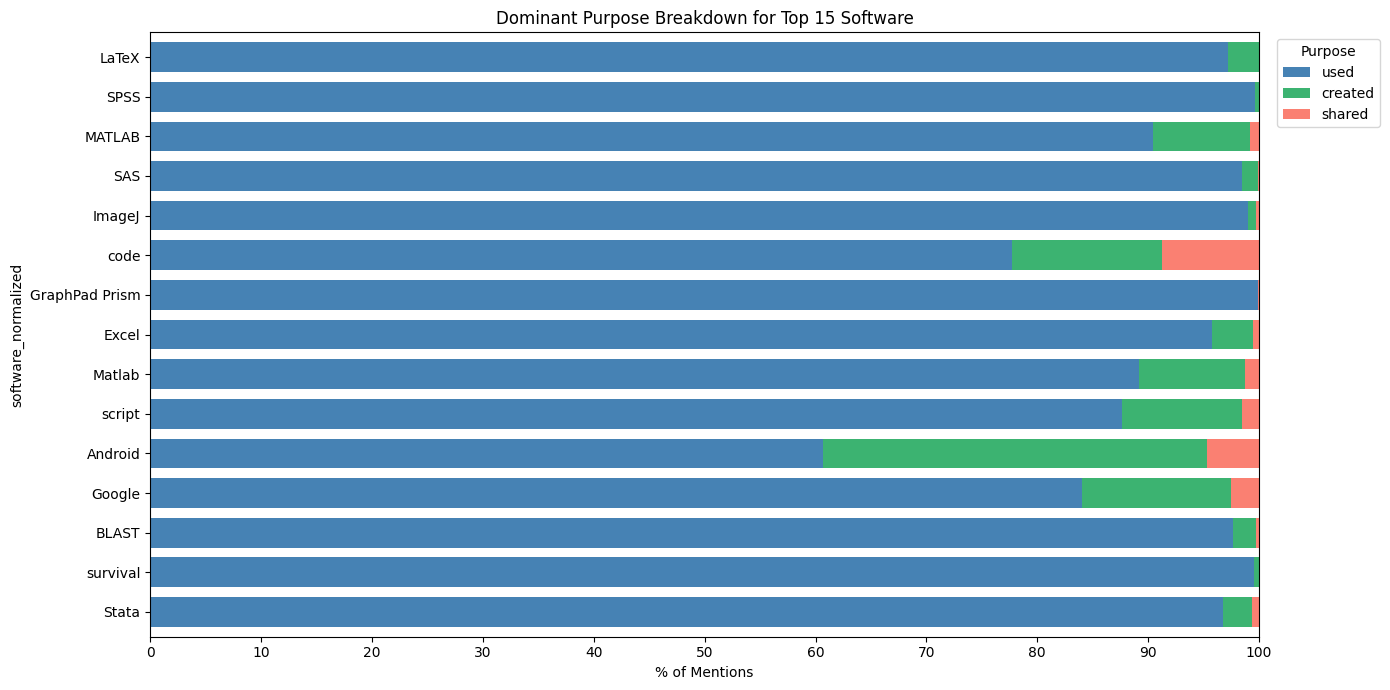


Raw counts (dominant purpose) per software:
purpose                used  created  shared
software_normalized                         
LaTeX                113921     3310      21
SPSS                  81551      292      37
MATLAB                28561     2736     270
SAS                   24849      373      16
ImageJ                24163      172      66
code                  17988     3122    2030
GraphPad Prism        21377        3      21
Excel                 20361      783     121
Matlab                15899     1696     234
script                12246     1514     211
Android                7524     4292     587
Google                10212     1640     303
BLAST                 11703      245      35
survival              11632       49       0
Stata                 11073      305      71


In [56]:
top_software = mentions_df['software_normalized'].value_counts().head(15).index.tolist()

merged = dominant_purpose.merge(
    mentions_df[['software_mention_id', 'software_normalized']],
    on='software_mention_id',
    how='inner'
)

top_merged = merged[merged['software_normalized'].isin(top_software)]

pivot = (top_merged.groupby(['software_normalized', 'purpose'])
         .size()
         .unstack(fill_value=0)
         .reindex(index=top_software, columns=['used', 'created', 'shared'], fill_value=0))

pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))
pivot_pct.plot(kind='barh', stacked=True, ax=ax,
               color=['steelblue', 'mediumseagreen', 'salmon'], width=0.75)
ax.set_xlabel("% of Mentions")
ax.set_title("Dominant Purpose Breakdown for Top 15 Software")
ax.legend(title="Purpose", bbox_to_anchor=(1.01, 1), loc='upper left')
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xticks(range(0, 101, 10))

plt.tight_layout()
plt.show()

print("\nRaw counts (dominant purpose) per software:")
print(pivot)

             field  count_with_value  pct_with_value
       version_raw            557504           20.07
version_normalized            557504           20.07


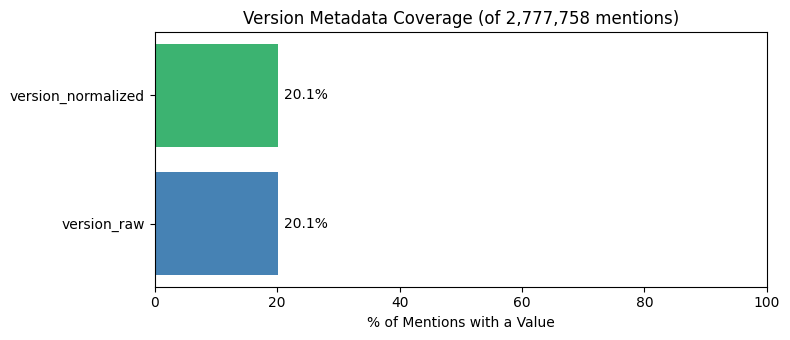

In [62]:
def non_empty(s):
    return s.notna() & (s.astype(str).str.strip() != "")

has_version_raw = non_empty(mentions_df['version_raw']).sum()
has_version_norm = non_empty(mentions_df['version_normalized']).sum()
total = len(mentions_df)

coverage = pd.DataFrame({
    "field": ["version_raw", "version_normalized"],
    "count_with_value": [has_version_raw, has_version_norm],
    "pct_with_value": [has_version_raw / total * 100, has_version_norm / total * 100],
})

print(coverage.round(2).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(coverage['field'], coverage['pct_with_value'],
               color=['steelblue', 'mediumseagreen'])
ax.set_xlabel("% of Mentions with a Value")
ax.set_title(f"Version Metadata Coverage (of {total:,} mentions)")
ax.set_xlim(0, 100)
for bar, v in zip(bars, coverage['pct_with_value']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
            f"{v:.1f}%", va='center', fontsize=10)
plt.tight_layout()
plt.show()

Top 20 software by distinct versions (with missing-version counts):
                     total_mentions  mentions_with_version  distinct_versions  \
software_normalized                                                             
SPSS                          81880                  64719                749   
ImageJ                        24401                   4786                546   
MATLAB                        31567                   7940                466   
Linux                         11369                   3355                420   
Excel                         21265                   5320                381   
SAS                           25238                  16779                333   
GraphPad Prism                21401                  17026                317   
Matlab                        17829                   3705                317   
MedCalc                        1548                   1098                256   
Image J                        5359      

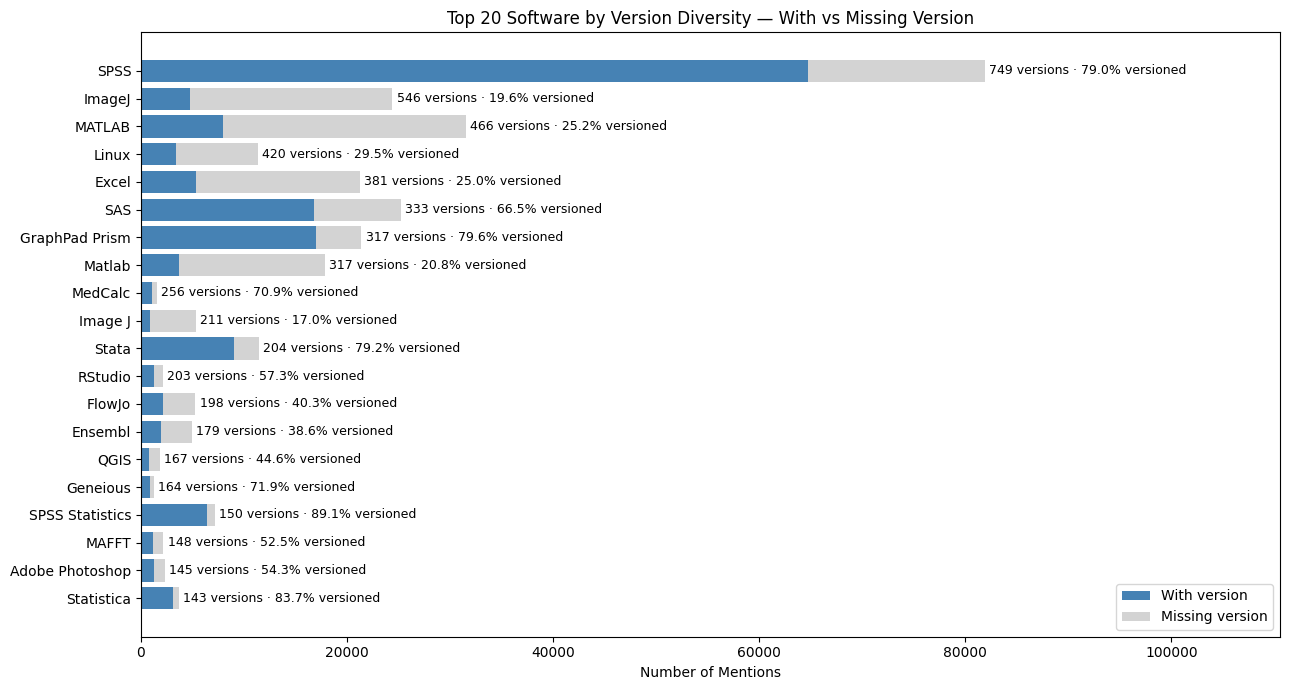

In [64]:
has_version = non_empty(mentions_df['version_normalized'])

version_stats = (mentions_df
    .assign(has_version=has_version)
    .groupby('software_normalized')
    .agg(total_mentions=('software_normalized', 'size'),
         mentions_with_version=('has_version', 'sum'),
         distinct_versions=('version_normalized', 'nunique'))
    .assign(mentions_missing_version=lambda d: d['total_mentions'] - d['mentions_with_version'],
            pct_with_version=lambda d: d['mentions_with_version'] / d['total_mentions'] * 100)
    .sort_values('distinct_versions', ascending=False)
    .head(20))

print("Top 20 software by distinct versions (with missing-version counts):")
print(version_stats.round(2))

fig, ax = plt.subplots(figsize=(13, 7))
y = np.arange(len(version_stats))
ax.barh(y, version_stats['mentions_with_version'],
        color='steelblue', label='With version')
ax.barh(y, version_stats['mentions_missing_version'],
        left=version_stats['mentions_with_version'],
        color='lightgray', label='Missing version')

ax.set_yticks(y)
ax.set_yticklabels(version_stats.index)
ax.invert_yaxis()
ax.set_xlabel("Number of Mentions")
ax.set_title("Top 20 Software by Version Diversity — With vs Missing Version")
ax.legend(loc='lower right')

for i, (with_v, pct, distinct) in enumerate(zip(
    version_stats['mentions_with_version'],
    version_stats['pct_with_version'],
    version_stats['distinct_versions']
)):
    total = version_stats['total_mentions'].iloc[i]
    ax.text(total + version_stats['total_mentions'].max() * 0.005, i,
            f"{distinct} versions · {pct:.1f}% versioned",
            va='center', fontsize=9)

ax.set_xlim(0, version_stats['total_mentions'].max() * 1.35)

plt.tight_layout()
plt.show()